250k random zinc drugs

Dataset loaded with 249455 compounds
Columns: ['smiles', 'logP', 'qed', 'SAS']

Missing values in each column:
smiles    0
logP      0
qed       0
SAS       0
dtype: int64


Validating SMILES: 100%|██████████| 249455/249455 [00:48<00:00, 5124.14it/s]



Valid SMILES: 249455 out of 249455 (100.00%)


Calculating MW: 100%|██████████| 249455/249455 [00:00<00:00, 476465.27it/s]



Summary Statistics:
                 qed           logP  molecular_weight            SAS
count  249455.000000  249455.000000     249455.000000  249455.000000
mean        0.728264       2.457093        332.139116       3.053235
std         0.139565       1.434330         61.943570       0.834796
min         0.111811      -6.876200        150.121000       1.132738
25%         0.645872       1.574810        290.451000       2.416627
50%         0.759878       2.605600        333.819000       2.892993
75%         0.835714       3.486760        368.458000       3.545533
max         0.947882       8.252100        500.000000       7.289283

Average QED score: 0.7283
Average molecular weight: 332.14 g/mol
Average LogP: 2.46
Average synthetic accessibility score: 3.05


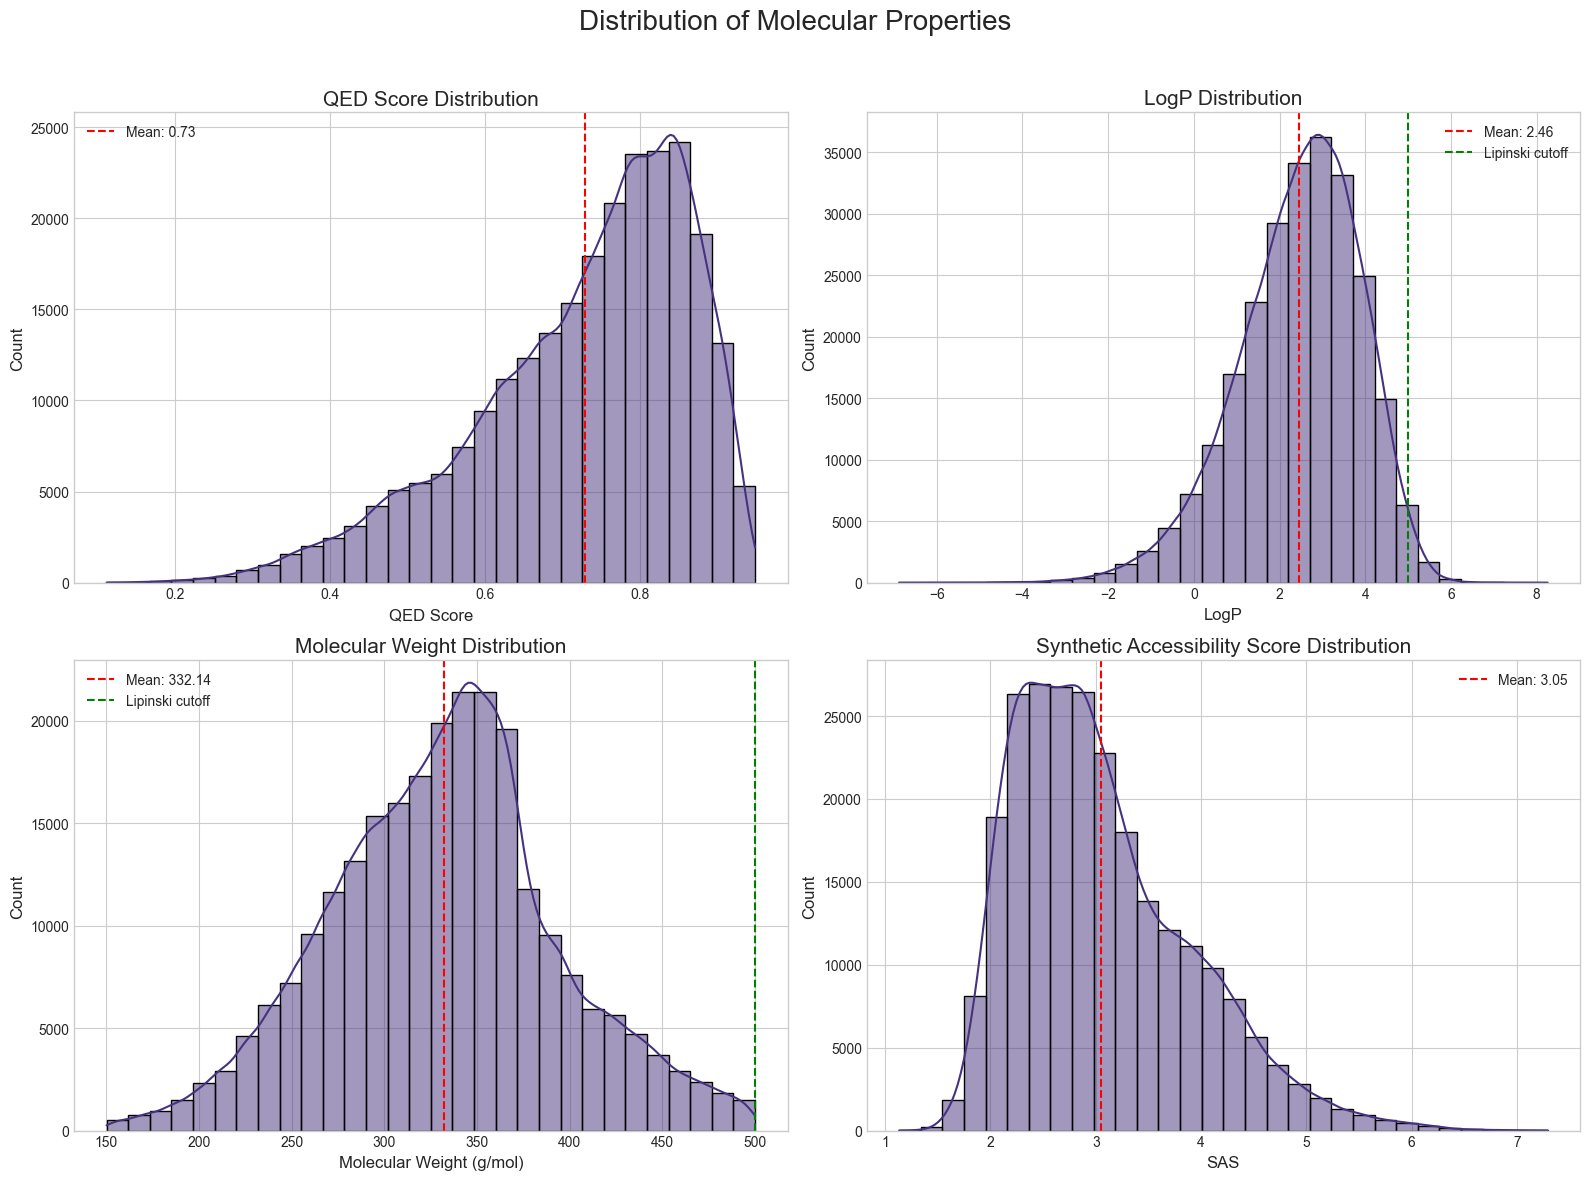

<Figure size 1400x1000 with 0 Axes>

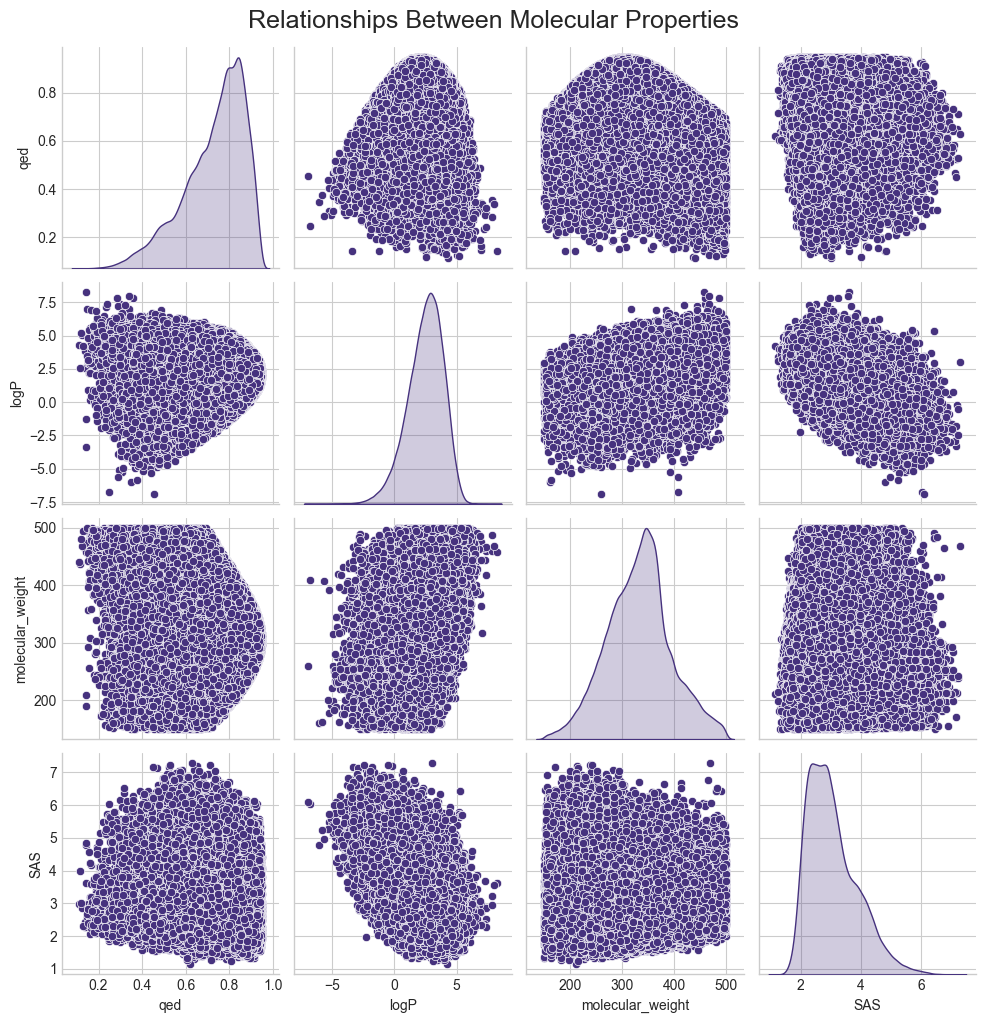


Lipinski's Rule of 5 Violations:
0 violations: 245431 compounds (98.39%)
1 violations: 4024 compounds (1.61%)

QED Score Distribution:
High: 161617 compounds (64.79%)
Low: 19209 compounds (7.70%)
Medium: 67312 compounds (26.98%)
Very Low: 1317 compounds (0.53%)

Processed dataframe saved to 'processed_molecules.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, QED
from tqdm import tqdm

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Load the dataset
file_path = r"C:\Users\kani1\OneDrive\Desktop\gdg_hackathon_25\MolGenX-api\MolGenX-backend\data\250k_rndm_zinc_drugs_clean_3.csv"  # Replace with your actual file path
df = pd.read_csv(file_path)

print(f"Dataset loaded with {len(df)} compounds")
print(f"Columns: {df.columns.tolist()}")

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)

# Validate SMILES strings
valid_mols = []
valid_indices = []
for i, smiles in tqdm(enumerate(df['smiles']), total=len(df), desc="Validating SMILES"):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        valid_mols.append(mol)
        valid_indices.append(i)

# Create a new dataframe with only valid molecules
valid_df = df.iloc[valid_indices].copy().reset_index(drop=True)
print(f"\nValid SMILES: {len(valid_df)} out of {len(df)} ({len(valid_df)/len(df)*100:.2f}%)")

# Calculate properties for molecules where they might be missing
if 'qed' not in df.columns or df['qed'].isnull().sum() > 0:
    valid_df['qed'] = [QED.qed(mol) for mol in tqdm(valid_mols, desc="Calculating QED")]

if 'logP' not in df.columns or df['logP'].isnull().sum() > 0:
    valid_df['logP'] = [Descriptors.MolLogP(mol) for mol in tqdm(valid_mols, desc="Calculating LogP")]

if 'molecular_weight' not in df.columns or df['molecular_weight'].isnull().sum() > 0:
    valid_df['molecular_weight'] = [Descriptors.MolWt(mol) for mol in tqdm(valid_mols, desc="Calculating MW")]

# Summary statistics
print("\nSummary Statistics:")
summary = valid_df[['qed', 'logP', 'molecular_weight', 'SAS']].describe()
print(summary)

# Calculate and display averages
avg_qed = valid_df['qed'].mean()
avg_mw = valid_df['molecular_weight'].mean()
avg_logp = valid_df['logP'].mean()
avg_sas = valid_df['SAS'].mean()

print(f"\nAverage QED score: {avg_qed:.4f}")
print(f"Average molecular weight: {avg_mw:.2f} g/mol")
print(f"Average LogP: {avg_logp:.2f}")
print(f"Average synthetic accessibility score: {avg_sas:.2f}")

# Distributions analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution of Molecular Properties', fontsize=20)

# QED Distribution
sns.histplot(valid_df['qed'], kde=True, bins=30, ax=axes[0, 0])
axes[0, 0].set_title('QED Score Distribution', fontsize=15)
axes[0, 0].set_xlabel('QED Score', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].axvline(avg_qed, color='red', linestyle='--', label=f'Mean: {avg_qed:.2f}')
axes[0, 0].legend()

# LogP Distribution
sns.histplot(valid_df['logP'], kde=True, bins=30, ax=axes[0, 1])
axes[0, 1].set_title('LogP Distribution', fontsize=15)
axes[0, 1].set_xlabel('LogP', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].axvline(avg_logp, color='red', linestyle='--', label=f'Mean: {avg_logp:.2f}')
# Add Lipinski rule line at LogP = 5
axes[0, 1].axvline(5, color='green', linestyle='--', label='Lipinski cutoff')
axes[0, 1].legend()

# Molecular Weight Distribution
sns.histplot(valid_df['molecular_weight'], kde=True, bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Molecular Weight Distribution', fontsize=15)
axes[1, 0].set_xlabel('Molecular Weight (g/mol)', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].axvline(avg_mw, color='red', linestyle='--', label=f'Mean: {avg_mw:.2f}')
# Add Lipinski rule line at MW = 500
axes[1, 0].axvline(500, color='green', linestyle='--', label='Lipinski cutoff')
axes[1, 0].legend()

# SAS Distribution
sns.histplot(valid_df['SAS'], kde=True, bins=30, ax=axes[1, 1])
axes[1, 1].set_title('Synthetic Accessibility Score Distribution', fontsize=15)
axes[1, 1].set_xlabel('SAS', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].axvline(avg_sas, color='red', linestyle='--', label=f'Mean: {avg_sas:.2f}')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('molecular_properties_distribution.png', dpi=300)
plt.show()

# Create pairplot to show relationships between properties
plt.figure(figsize=(14, 10))
sns.pairplot(valid_df[['qed', 'logP', 'molecular_weight', 'SAS']], diag_kind='kde')
plt.suptitle('Relationships Between Molecular Properties', y=1.02, fontsize=18)
plt.savefig('molecular_properties_pairplot.png', dpi=300)
plt.show()

# Drug-likeness analysis (Lipinski's Rule of 5)
def lipinski_violations(mol):
    """Count Lipinski's Rule of 5 violations"""
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)
    
    violations = 0
    if mw > 500: violations += 1
    if logp > 5: violations += 1
    if h_donors > 5: violations += 1
    if h_acceptors > 10: violations += 1
    
    return violations

lipinski_counts = [lipinski_violations(mol) for mol in valid_mols]
valid_df['lipinski_violations'] = lipinski_counts

violation_counts = valid_df['lipinski_violations'].value_counts().sort_index()
print("\nLipinski's Rule of 5 Violations:")
for violations, count in violation_counts.items():
    print(f"{violations} violations: {count} compounds ({count/len(valid_df)*100:.2f}%)")

# Categorize QED scores
qed_ranges = [
    (0, 0.3, 'Very Low'),
    (0.3, 0.5, 'Low'),
    (0.5, 0.7, 'Medium'),
    (0.7, 1.0, 'High')
]

# Create QED category column
valid_df['qed_category'] = 'Unknown'
for low, high, label in qed_ranges:
    mask = (valid_df['qed'] >= low) & (valid_df['qed'] < high)
    valid_df.loc[mask, 'qed_category'] = label

qed_category_counts = valid_df['qed_category'].value_counts().sort_index()
print("\nQED Score Distribution:")
for category, count in qed_category_counts.items():
    print(f"{category}: {count} compounds ({count/len(valid_df)*100:.2f}%)")

# Save the processed dataframe
valid_df.to_csv('processed_molecules.csv', index=False)

print("\nProcessed dataframe saved to 'processed_molecules.csv'")

PDB Bind 2020 (protien-ligand pairs)

Dataset loaded with 14122 compounds
Columns: ['pdb_id', 'smiles', 'qed', 'logp', 'molecular_weight', 'target_seq', 'protein_title', 'retrieval_success']

Missing values in each column:
pdb_id                 0
smiles                 0
qed                   71
logp                  71
molecular_weight      71
target_seq           902
protein_title        902
retrieval_success      0
dtype: int64
Retrieval success rate: 93.61%

Entries with successfully retrieved protein sequences: 13220 out of 14122 (93.61%)


Validating SMILES:   2%|▏         | 242/14122 [00:00<00:05, 2402.24it/s][13:42:18] Explicit valence for atom # 16 C, 5, is greater than permitted
[13:42:18] Can't kekulize mol.  Unkekulized atoms: 0 1 2 5 6
Validating SMILES:  12%|█▏        | 1628/14122 [00:00<00:03, 3405.21it/s][13:42:19] Explicit valence for atom # 27 C, 5, is greater than permitted
[13:42:19] Explicit valence for atom # 29 C, 5, is greater than permitted
Validating SMILES:  19%|█▊        | 2638/14122 [00:00<00:03, 3018.60it/s][13:42:19] Explicit valence for atom # 4 C, 5, is greater than permitted
[13:42:19] Can't kekulize mol.  Unkekulized atoms: 2 17
Validating SMILES:  24%|██▍       | 3357/14122 [00:01<00:03, 3078.21it/s][13:42:19] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[13:42:19] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[13:42:19] Explicit valence for atom # 11 C, 5, is greater than permitted
Validating SMILES: 


Valid SMILES: 14051 out of 14122 (99.50%)

Molecular Property Summary Statistics:
                qed          logp  molecular_weight
count  14051.000000  14051.000000      14051.000000
mean       0.419274     -0.289456        510.235267
std        0.253842      5.177927        344.835394
min        0.007287    -33.927100         56.881000
25%        0.217078     -2.875750        312.424000
50%        0.431615      1.468900        416.526000
75%        0.623673      3.206410        553.607000
max        0.946529     14.014300       3042.056000

Average QED score: 0.4193
Average molecular weight: 510.24 g/mol
Average LogP: -0.29

Protein Sequence Summary Statistics:
count    13157.000000
mean       317.535228
std        184.562776
min          4.000000
25%        205.000000
50%        292.000000
75%        375.000000
max       2739.000000
Name: protein_length, dtype: float64
Unique protein sequences: 6043
Unique PDB IDs: 13157

Protein length distribution:
<100: 812 proteins (6.17%)
10

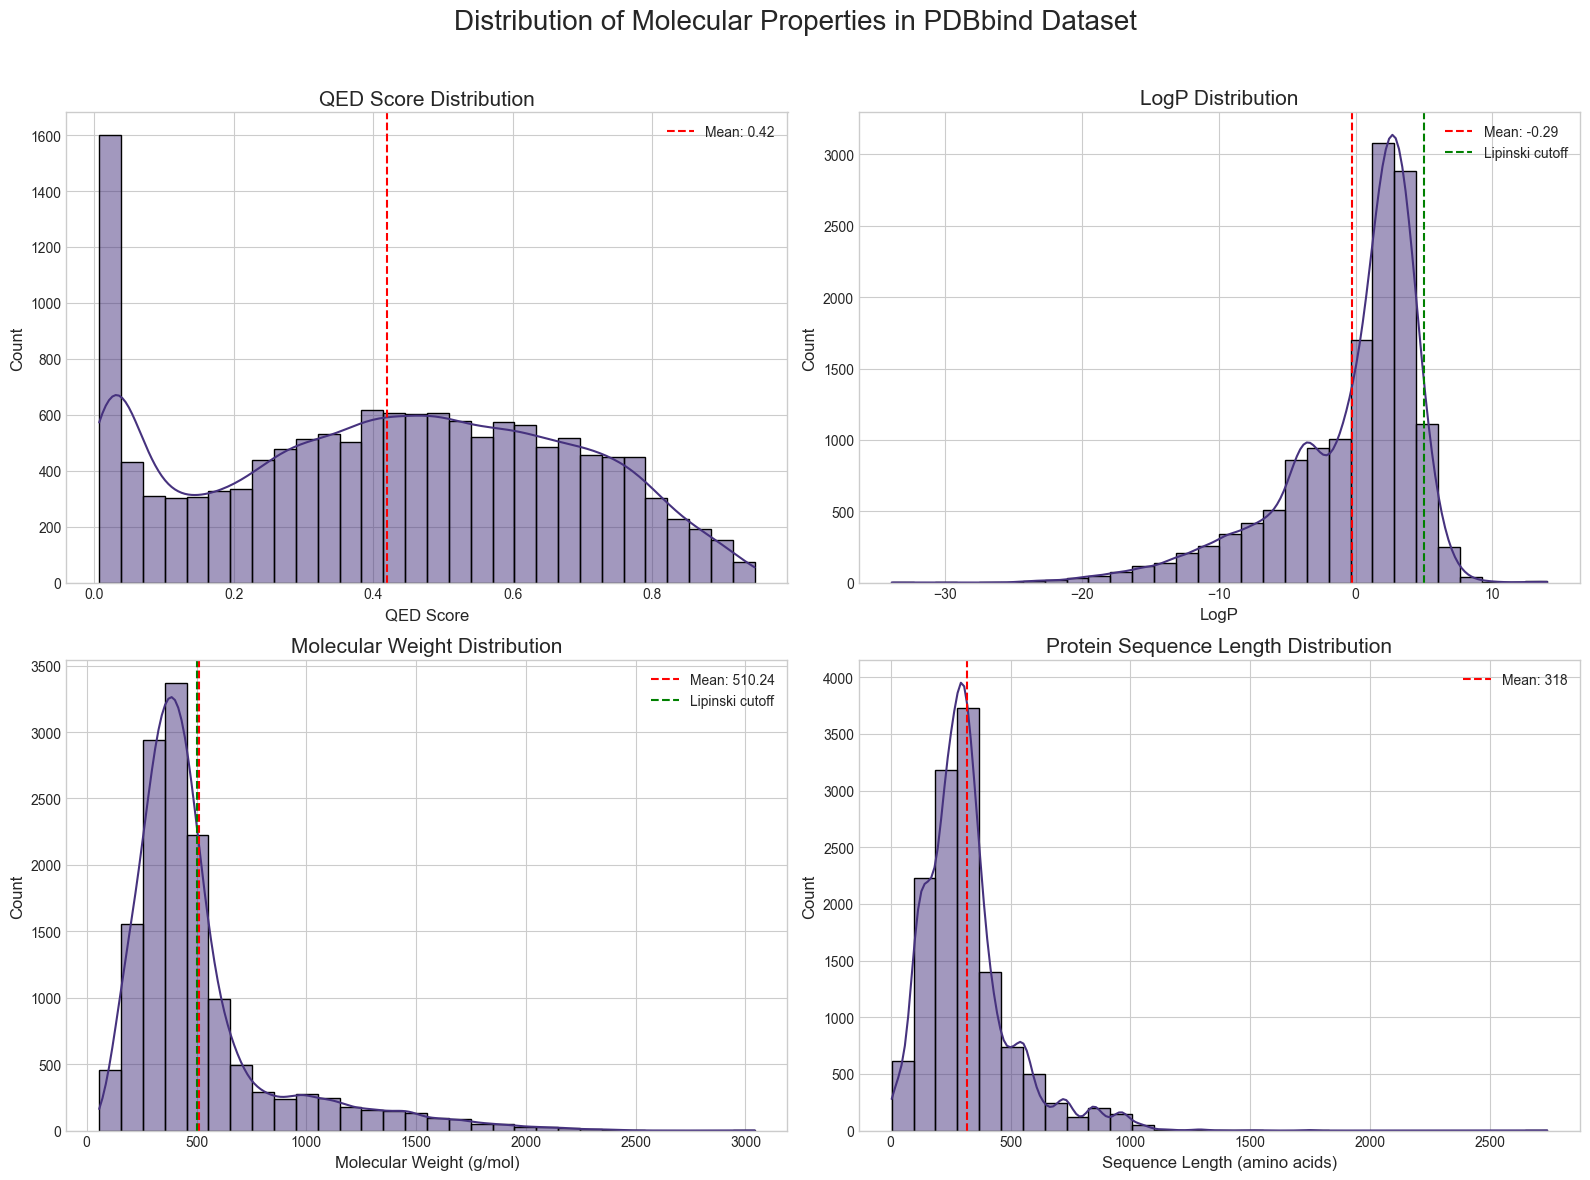

<Figure size 1400x1000 with 0 Axes>

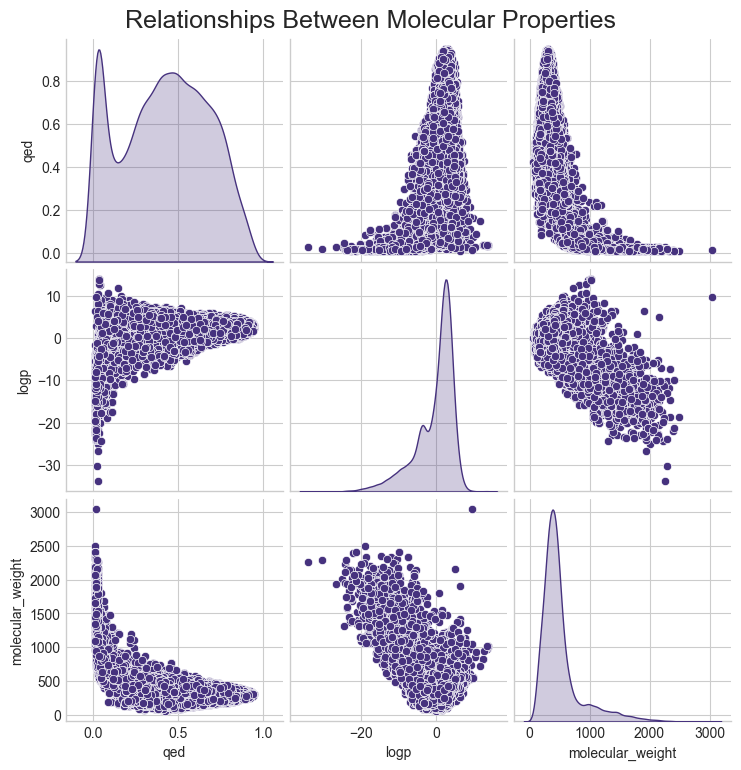


Lipinski's Rule of 5 Violations:
0 violations: 8422 compounds (59.94%)
1 violations: 2247 compounds (15.99%)
2 violations: 1337 compounds (9.52%)
3 violations: 2038 compounds (14.50%)
4 violations: 7 compounds (0.05%)

QED Score Distribution:
High: 2239 compounds (15.93%)
Low: 3634 compounds (25.86%)
Medium: 3466 compounds (24.67%)
Very Low: 4712 compounds (33.53%)

Ligands per protein target:
  Mean: 2.18
  Median: 1
  Min: 1
  Max: 101
  Targets with only one ligand: 3938 (65.17%)


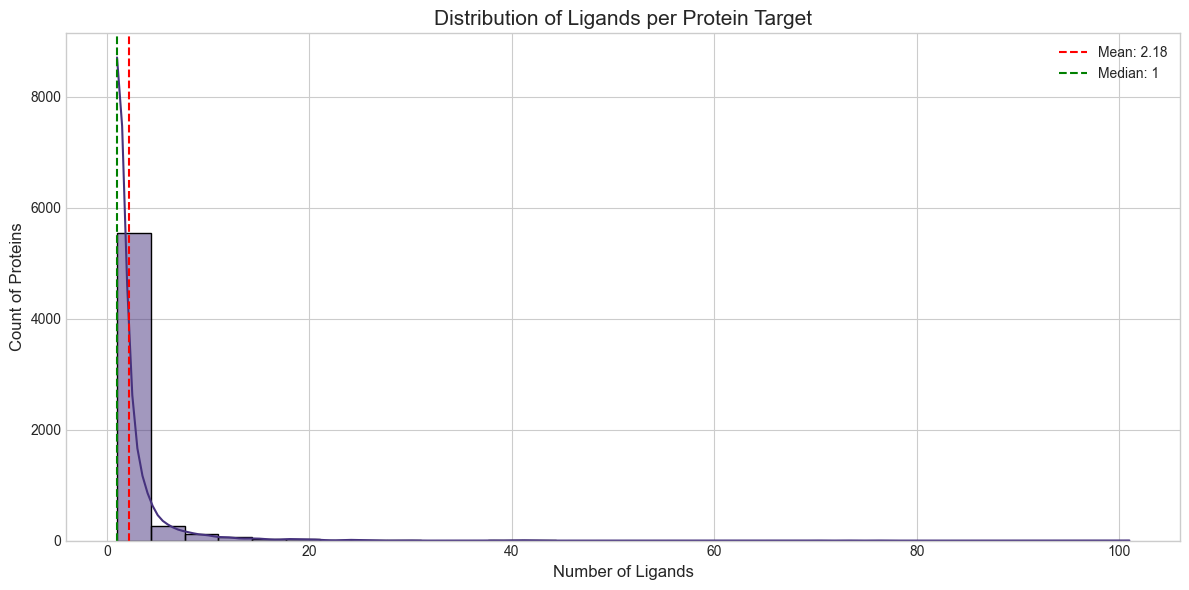


Top 10 protein targets by number of ligands:
                                       protein_title pdb_id  sequence_length  \
0  HUMAN CYCLIN DEPENDENT KINASE 2 COMPLEXED WITH...   1aq1              298   
1            TRYPSIN WITH INHIBITOR AERUGINOSIN 98-B   1aq7              223   
2  Crystal structure of the yeast 20S proteasome ...   3gpj              250   
3  Crystal Structure of the first bromodomain of ...   3mxf              127   
4  Structure of thrombin inhibited by AERUGINOSIN...   1a2c               36   
5  COOPERATIVITY BETWEEN HYDROGEN-BONDING AND CHA...   1axr              842   
6  CRYSTAL STRUCTURE OF HUMAN CARBONIC ANHYDRASE ...   1eou              260   
7  Ligand complex structure of soluble epoxide hy...   5ai0              549   
8  AMPC BETA-LACTAMASE FROM E. COLI COMPLEXED WIT...   1c3b              358   
9  Crystal structure of human FXR in complex with...   3okh              233   

   ligand_count  
0           101  
1            76  
2            73  
3

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, QED
from tqdm import tqdm

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Load the dataset
file_path = r"C:\Users\kani1\OneDrive\Desktop\gdg_hackathon_25\MolGenX-api\MolGenX-backend\data\PDB_bind_2020_with_prop_seq.csv"  # Update with your file path
df = pd.read_csv(file_path)

print(f"Dataset loaded with {len(df)} compounds")
print(f"Columns: {df.columns.tolist()}")

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)
print(f"Retrieval success rate: {df['retrieval_success'].mean()*100:.2f}%")

# Filter rows where protein sequence retrieval was successful
if 'retrieval_success' in df.columns:
    df_with_proteins = df[df['retrieval_success'] == True].copy()
    print(f"\nEntries with successfully retrieved protein sequences: {len(df_with_proteins)} out of {len(df)} ({len(df_with_proteins)/len(df)*100:.2f}%)")
else:
    df_with_proteins = df.copy()

# Validate SMILES strings
valid_mols = []
valid_indices = []
invalid_smiles = []

for i, smiles in tqdm(enumerate(df['smiles']), total=len(df), desc="Validating SMILES"):
    if pd.isna(smiles):
        invalid_smiles.append(i)
        continue
        
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        valid_mols.append(mol)
        valid_indices.append(i)
    else:
        invalid_smiles.append(i)

# Create a new dataframe with only valid molecules
valid_df = df.iloc[valid_indices].copy().reset_index(drop=True)
print(f"\nValid SMILES: {len(valid_df)} out of {len(df)} ({len(valid_df)/len(df)*100:.2f}%)")

# Calculate missing properties
if 'qed' not in valid_df.columns or valid_df['qed'].isnull().sum() > 0:
    print("Calculating QED values...")
    valid_df['qed'] = [QED.qed(mol) for mol in tqdm(valid_mols, desc="Calculating QED")]

if 'logp' not in valid_df.columns or valid_df['logp'].isnull().sum() > 0:
    print("Calculating LogP values...")
    valid_df['logp'] = [Descriptors.MolLogP(mol) for mol in tqdm(valid_mols, desc="Calculating LogP")]

if 'molecular_weight' not in valid_df.columns or valid_df['molecular_weight'].isnull().sum() > 0:
    print("Calculating molecular weight values...")
    valid_df['molecular_weight'] = [Descriptors.MolWt(mol) for mol in tqdm(valid_mols, desc="Calculating MW")]

# Summary statistics for molecular properties
print("\nMolecular Property Summary Statistics:")
summary = valid_df[['qed', 'logp', 'molecular_weight']].describe()
print(summary)

# Calculate and display averages
avg_qed = valid_df['qed'].mean()
avg_mw = valid_df['molecular_weight'].mean()
avg_logp = valid_df['logp'].mean()

print(f"\nAverage QED score: {avg_qed:.4f}")
print(f"Average molecular weight: {avg_mw:.2f} g/mol")
print(f"Average LogP: {avg_logp:.2f}")

# Protein sequence statistics
if 'target_seq' in valid_df.columns:
    # Filter out missing sequences
    seq_df = valid_df.dropna(subset=['target_seq'])
    
    # Calculate sequence lengths
    seq_df['protein_length'] = seq_df['target_seq'].str.len()
    
    # Summary statistics for protein sequences
    print("\nProtein Sequence Summary Statistics:")
    protein_summary = seq_df['protein_length'].describe()
    print(protein_summary)
    
    # Count unique protein sequences
    unique_proteins = seq_df['target_seq'].nunique()
    unique_pdbs = seq_df['pdb_id'].nunique()
    print(f"Unique protein sequences: {unique_proteins}")
    print(f"Unique PDB IDs: {unique_pdbs}")
    
    # Distribution of protein lengths
    print(f"\nProtein length distribution:")
    bins = [0, 100, 200, 300, 400, 500, 1000, 5000]
    labels = ['<100', '100-200', '200-300', '300-400', '400-500', '500-1000', '>1000']
    seq_df['length_category'] = pd.cut(seq_df['protein_length'], bins=bins, labels=labels)
    length_counts = seq_df['length_category'].value_counts().sort_index()
    
    for category, count in length_counts.items():
        print(f"{category}: {count} proteins ({count/len(seq_df)*100:.2f}%)")

# Molecular property distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution of Molecular Properties in PDBbind Dataset', fontsize=20)

# QED Distribution
sns.histplot(valid_df['qed'], kde=True, bins=30, ax=axes[0, 0])
axes[0, 0].set_title('QED Score Distribution', fontsize=15)
axes[0, 0].set_xlabel('QED Score', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].axvline(avg_qed, color='red', linestyle='--', label=f'Mean: {avg_qed:.2f}')
axes[0, 0].legend()

# LogP Distribution
sns.histplot(valid_df['logp'], kde=True, bins=30, ax=axes[0, 1])
axes[0, 1].set_title('LogP Distribution', fontsize=15)
axes[0, 1].set_xlabel('LogP', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].axvline(avg_logp, color='red', linestyle='--', label=f'Mean: {avg_logp:.2f}')
# Add Lipinski rule line at LogP = 5
axes[0, 1].axvline(5, color='green', linestyle='--', label='Lipinski cutoff')
axes[0, 1].legend()

# Molecular Weight Distribution
sns.histplot(valid_df['molecular_weight'], kde=True, bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Molecular Weight Distribution', fontsize=15)
axes[1, 0].set_xlabel('Molecular Weight (g/mol)', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].axvline(avg_mw, color='red', linestyle='--', label=f'Mean: {avg_mw:.2f}')
# Add Lipinski rule line at MW = 500
axes[1, 0].axvline(500, color='green', linestyle='--', label='Lipinski cutoff')
axes[1, 0].legend()

# Protein Length Distribution
if 'target_seq' in valid_df.columns:
    sns.histplot(seq_df['protein_length'], kde=True, bins=30, ax=axes[1, 1])
    axes[1, 1].set_title('Protein Sequence Length Distribution', fontsize=15)
    axes[1, 1].set_xlabel('Sequence Length (amino acids)', fontsize=12)
    axes[1, 1].set_ylabel('Count', fontsize=12)
    axes[1, 1].axvline(seq_df['protein_length'].mean(), color='red', linestyle='--', 
                       label=f'Mean: {seq_df["protein_length"].mean():.0f}')
    axes[1, 1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('pdbbind_properties_distribution.png', dpi=300)
plt.show()

# Create pairplot to show relationships between properties
plt.figure(figsize=(14, 10))
sns.pairplot(valid_df[['qed', 'logp', 'molecular_weight']], diag_kind='kde')
plt.suptitle('Relationships Between Molecular Properties', y=1.02, fontsize=18)
plt.savefig('pdbbind_properties_pairplot.png', dpi=300)
plt.show()

# Drug-likeness analysis (Lipinski's Rule of 5)
def lipinski_violations(mol):
    """Count Lipinski's Rule of 5 violations"""
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)
    
    violations = 0
    if mw > 500: violations += 1
    if logp > 5: violations += 1
    if h_donors > 5: violations += 1
    if h_acceptors > 10: violations += 1
    
    return violations

lipinski_counts = [lipinski_violations(mol) for mol in valid_mols]
valid_df['lipinski_violations'] = lipinski_counts

violation_counts = valid_df['lipinski_violations'].value_counts().sort_index()
print("\nLipinski's Rule of 5 Violations:")
for violations, count in violation_counts.items():
    print(f"{violations} violations: {count} compounds ({count/len(valid_df)*100:.2f}%)")

# Categorize QED scores
qed_ranges = [
    (0, 0.3, 'Very Low'),
    (0.3, 0.5, 'Low'),
    (0.5, 0.7, 'Medium'),
    (0.7, 1.0, 'High')
]

# Create QED category column
valid_df['qed_category'] = 'Unknown'
for low, high, label in qed_ranges:
    mask = (valid_df['qed'] >= low) & (valid_df['qed'] < high)
    valid_df.loc[mask, 'qed_category'] = label

qed_category_counts = valid_df['qed_category'].value_counts().sort_index()
print("\nQED Score Distribution:")
for category, count in qed_category_counts.items():
    print(f"{category}: {count} compounds ({count/len(valid_df)*100:.2f}%)")

# Additional analysis for protein-ligand dataset
if 'target_seq' in valid_df.columns and 'pdb_id' in valid_df.columns:
    # Count ligands per protein target
    ligands_per_target = valid_df.groupby('target_seq').size()
    
    print("\nLigands per protein target:")
    print(f"  Mean: {ligands_per_target.mean():.2f}")
    print(f"  Median: {ligands_per_target.median():.0f}")
    print(f"  Min: {ligands_per_target.min()}")
    print(f"  Max: {ligands_per_target.max()}")
    print(f"  Targets with only one ligand: {(ligands_per_target == 1).sum()} ({(ligands_per_target == 1).sum()/len(ligands_per_target)*100:.2f}%)")
    
    # Create visualization of ligands per target distribution
    plt.figure(figsize=(12, 6))
    sns.histplot(ligands_per_target.values, bins=30, kde=True)
    plt.title('Distribution of Ligands per Protein Target', fontsize=15)
    plt.xlabel('Number of Ligands', fontsize=12)
    plt.ylabel('Count of Proteins', fontsize=12)
    plt.axvline(ligands_per_target.mean(), color='red', linestyle='--', label=f'Mean: {ligands_per_target.mean():.2f}')
    plt.axvline(ligands_per_target.median(), color='green', linestyle='--', label=f'Median: {ligands_per_target.median():.0f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig('ligands_per_target_distribution.png', dpi=300)
    plt.show()
    
    # Analyze top protein targets
    top_targets = ligands_per_target.sort_values(ascending=False).head(10)
    top_target_details = []
    
    for target_seq, count in top_targets.items():
        # Find a row with this target sequence to get the title
        sample_row = valid_df[valid_df['target_seq'] == target_seq].iloc[0]
        top_target_details.append({
            'protein_title': sample_row['protein_title'] if 'protein_title' in sample_row else 'Unknown',
            'pdb_id': sample_row['pdb_id'],
            'sequence_length': len(target_seq),
            'ligand_count': count
        })
    
    top_targets_df = pd.DataFrame(top_target_details)
    print("\nTop 10 protein targets by number of ligands:")
    print(top_targets_df)

# Save the processed dataframe with all computed properties
valid_df.to_csv('pdbbind_processed_properties.csv', index=False)
print("\nProcessed dataframe saved to 'pdbbind_processed_properties.csv'")

Binding DB dataset (protien-compound pairs with log normalized affinity values >0.6, affinity types Ki, Kd, IC50,EC50)

Dataset loaded with 916228 compound-protein pairs
Columns: ['smiles', 'target_seq', 'affinity', 'AffinityType']

Missing values in each column:
smiles          0
target_seq      0
affinity        0
AffinityType    0
dtype: int64

Affinity Types:
AffinityType
IC50    625441
Ki      194344
EC50     80836
Kd       15607
Name: count, dtype: int64

Filtered dataset contains 916228 rows after removing missing values


Validating SMILES:   0%|          | 2334/916228 [00:00<03:13, 4720.00it/s][13:50:37] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 12 29 30
[13:50:37] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 12 30 31
Validating SMILES:   2%|▏         | 19413/916228 [00:04<04:01, 3714.34it/s][13:50:41] Can't kekulize mol.  Unkekulized atoms: 8 9 10 12 14 15 16
[13:50:41] Can't kekulize mol.  Unkekulized atoms: 25 26 27 28 29 30 32 33 34
Validating SMILES:   2%|▏         | 22849/916228 [00:05<03:50, 3877.88it/s][13:50:42] Explicit valence for atom # 10 N, 4, is greater than permitted
[13:50:42] Explicit valence for atom # 64 N, 4, is greater than permitted
[13:50:42] Explicit valence for atom # 66 N, 4, is greater than permitted
Validating SMILES:   3%|▎         | 29242/916228 [00:07<04:00, 3682.44it/s][13:50:44] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 18 19 20 21 22
[13:50:44] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 18 19 20 21 22
Validating SMILES:   3%|▎      


Valid SMILES: 915218 out of 916228 (99.89%)
Calculating molecular properties...


Calculating MW: 100%|██████████| 915218/915218 [00:17<00:00, 52612.28it/s] 



Molecular Property Summary Statistics:
                 qed           logp  molecular_weight       affinity
count  915218.000000  915218.000000     915218.000000  915218.000000
mean        0.508743       3.613185        454.436372       0.874250
std         0.211850       2.193474        228.961868       0.046434
min         0.002686     -74.746900          6.941000       0.600017
25%         0.356371       2.658400        360.461000       0.850693
50%         0.512716       3.716200        429.523500       0.884781
75%         0.675281       4.773780        502.583000       0.906864
max         0.948329     180.517200      12546.318000       1.000000

Average QED score: 0.5087
Average molecular weight: 454.44 g/mol
Average LogP: 3.61
Average affinity value: 0.8742

Protein Sequence Summary Statistics:
count    915218.000000
mean        697.137021
std         620.187940
min          55.000000
25%         391.000000
50%         501.000000
75%         804.000000
max        7182.000000
N

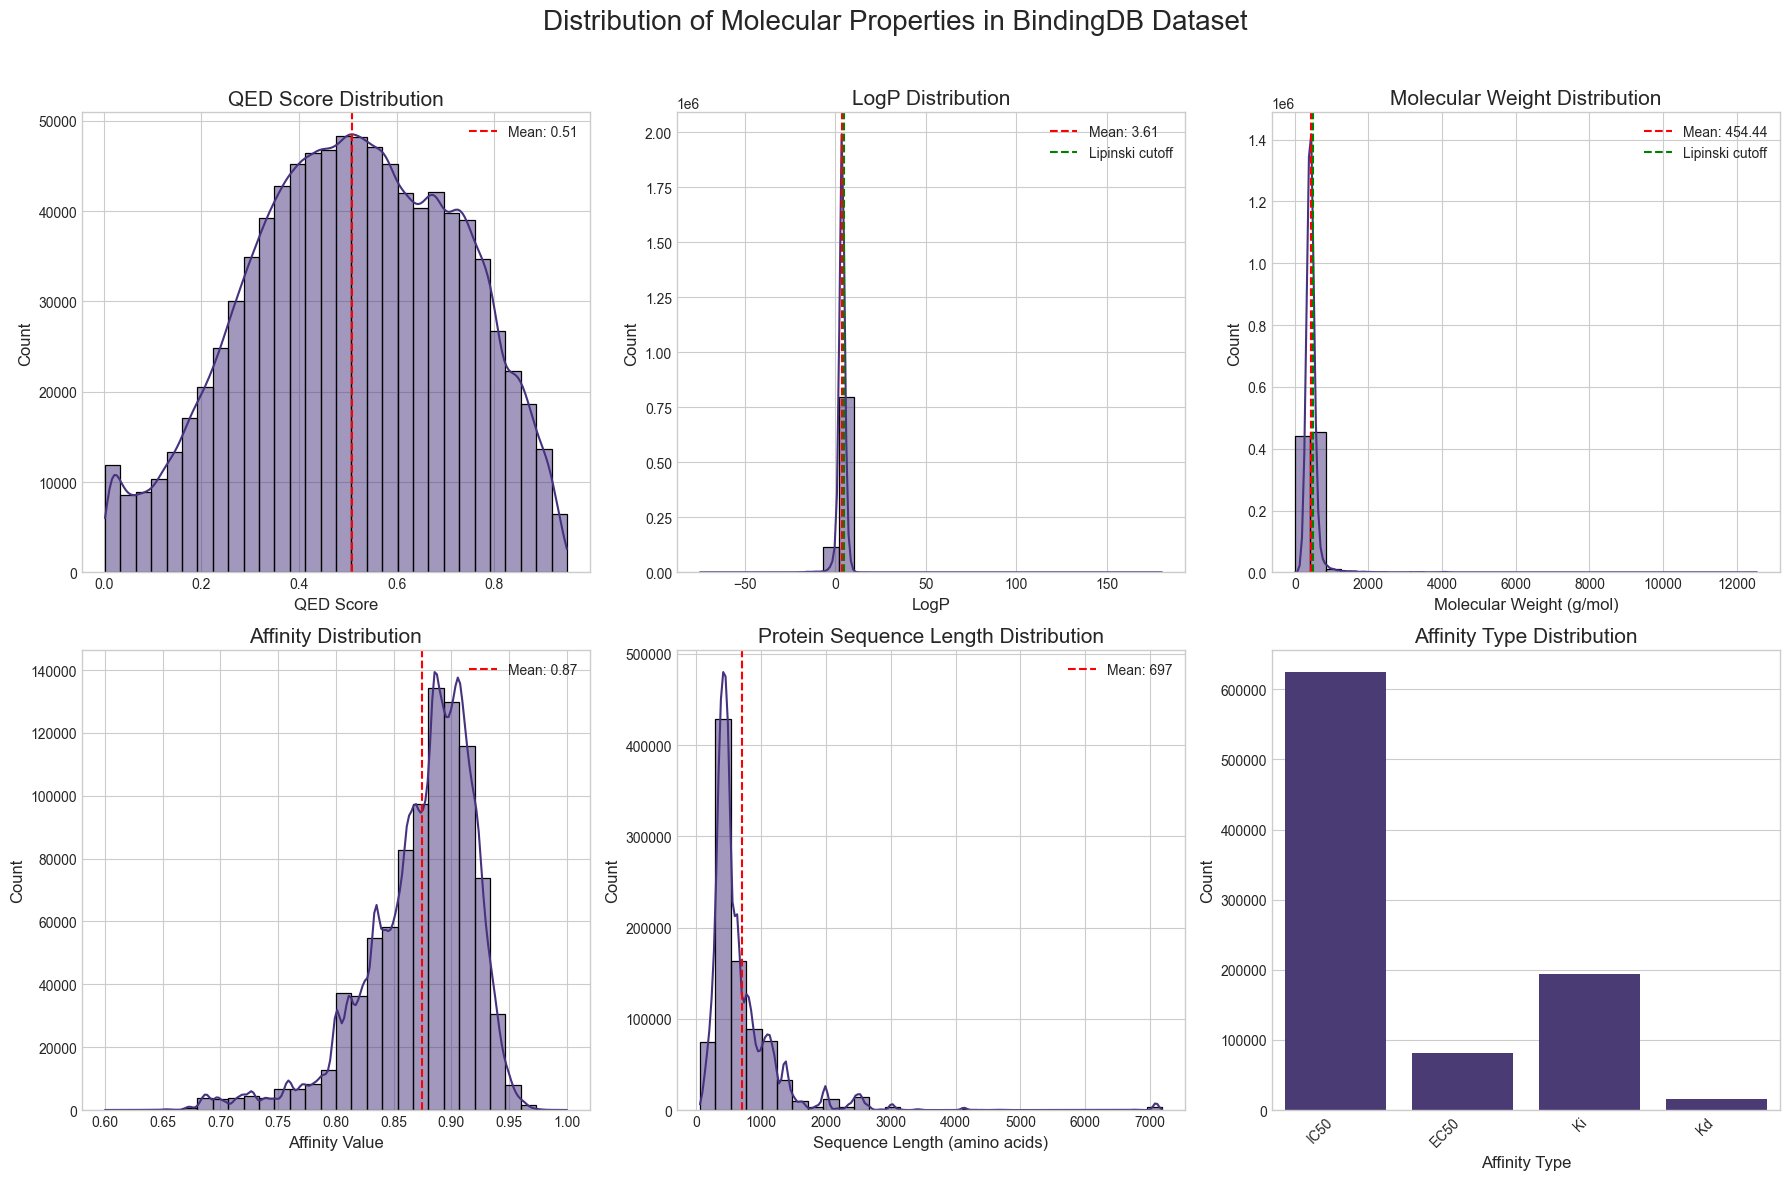

Generating pairplot (this may take a while for large datasets)...


<Figure size 1400x1000 with 0 Axes>

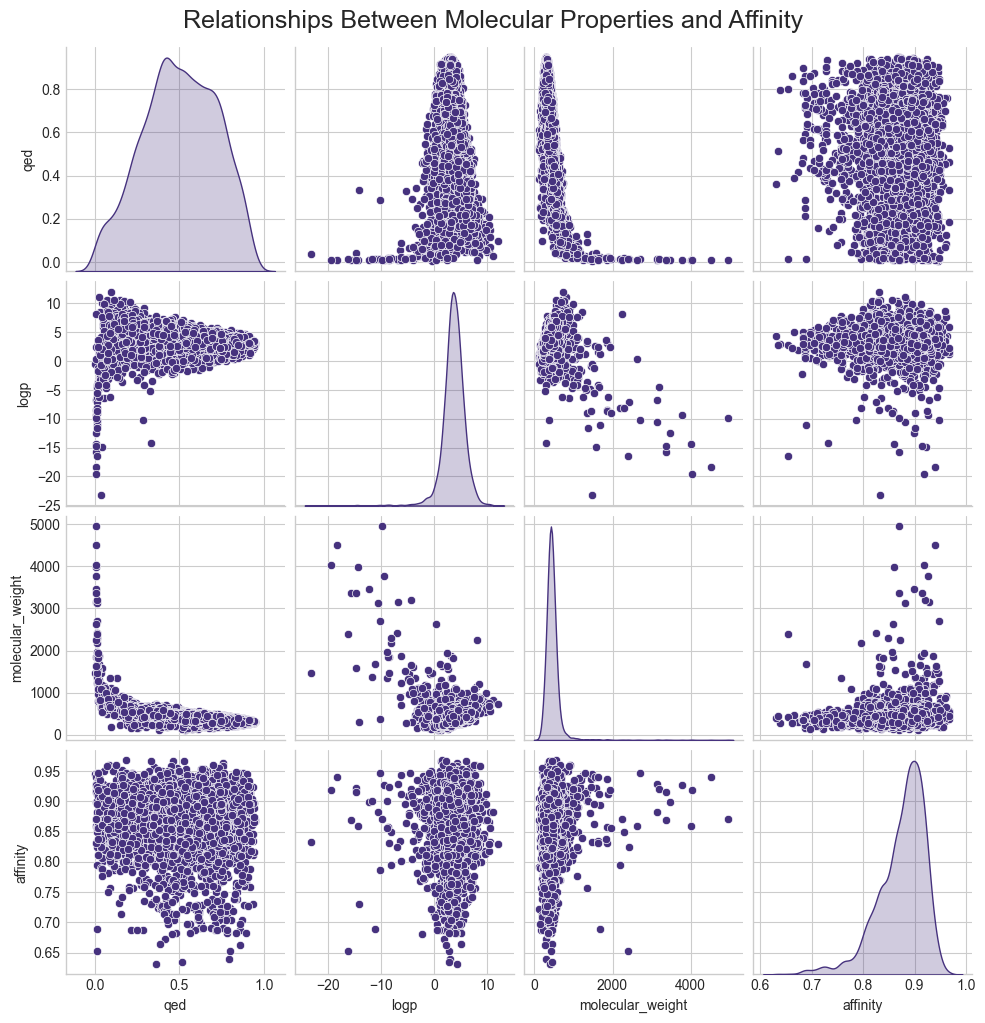


Lipinski's Rule of 5 Violations:
0 violations: 579311 compounds (63.30%)
1 violations: 202652 compounds (22.14%)
2 violations: 111018 compounds (12.13%)
3 violations: 21378 compounds (2.34%)
4 violations: 859 compounds (0.09%)

QED Score Distribution:
High: 196725 compounds (21.49%)
Low: 277871 compounds (30.36%)
Medium: 280628 compounds (30.66%)
Very Low: 159994 compounds (17.48%)

Correlation between affinity and molecular properties:
affinity            1.000000
qed                -0.127485
logp                0.074888
molecular_weight    0.141588
Name: affinity, dtype: float64

Analyzing molecular properties by affinity range...

Average properties by affinity range:
                     qed      logp  molecular_weight
affinity_range                                      
(0.599, 0.851]  0.542774  3.382647        410.846882
(0.851, 0.885]  0.519220  3.618936        444.197124
(0.885, 0.907]  0.497977  3.723193        467.360153
(0.907, 1.0]    0.474750  3.728109        495.645586


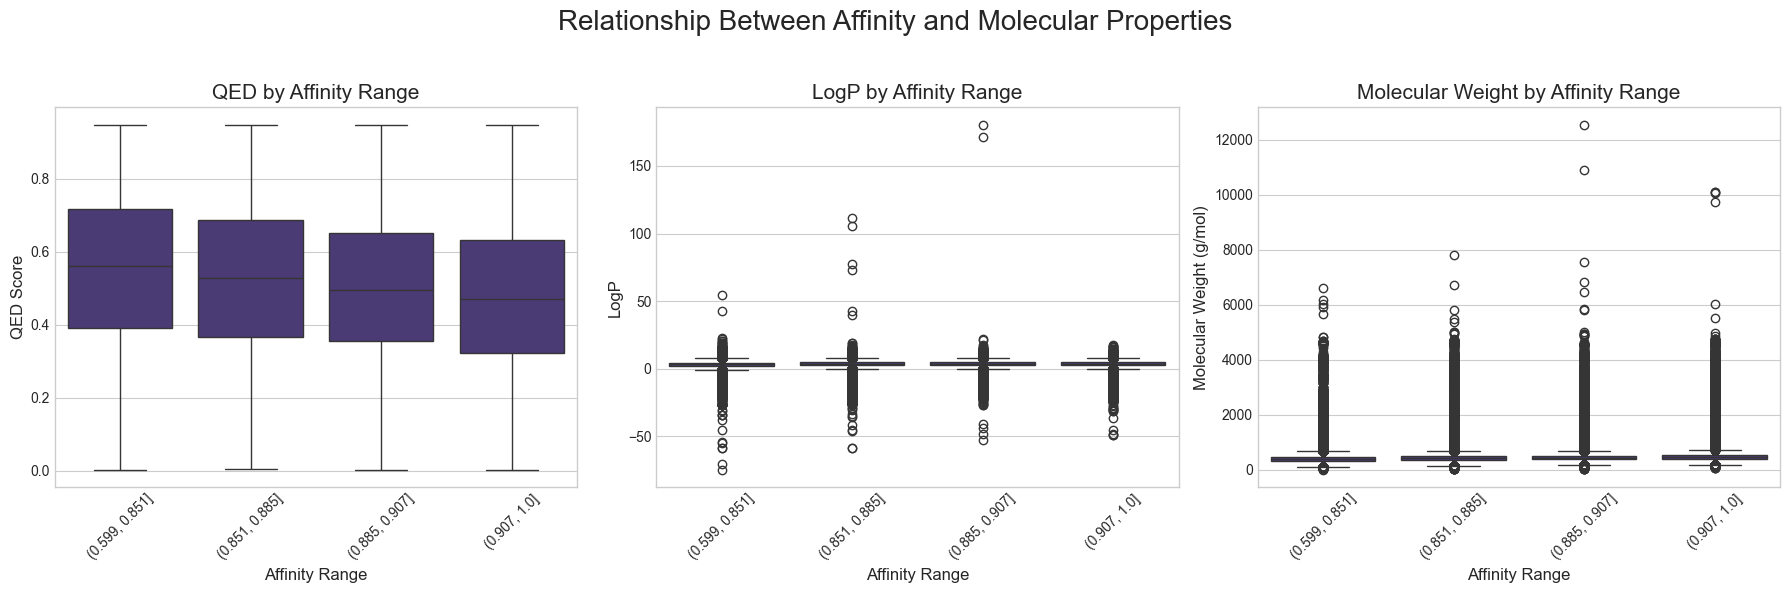


Ligands per protein target:
  Mean: 201.59
  Median: 21
  Min: 1
  Max: 9221
  Targets with only one ligand: 512 (11.28%)


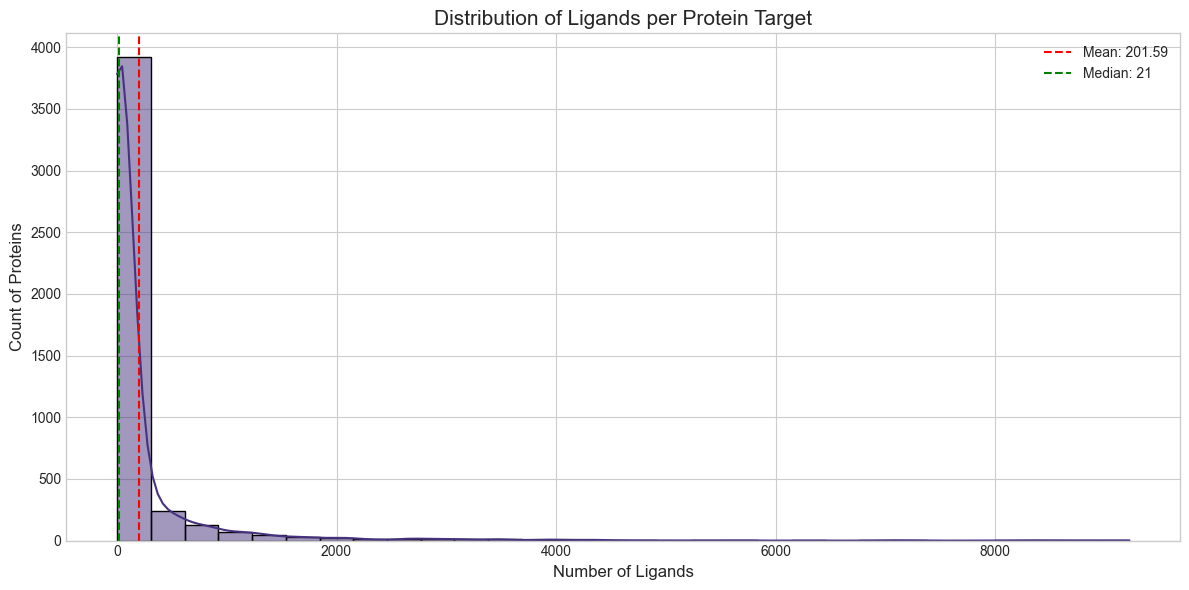


Top 10 protein targets by number of ligands:
   sequence_length  ligand_count  avg_affinity  \
0              659          9221      0.893205   
1             1988          8849      0.873889   
2              518          8380      0.891588   
3              460          8237      0.894899   
4             1210          7092      0.880182   
5              501          7053      0.880781   
6             1044          6169      0.894269   
7             1154          5666      0.909695   
8              360          5599      0.873654   
9              360          5316      0.903161   

                                     sequence_prefix  
0  MAAVILESIFLKRSQQKKKTSPLNFKKRLFLLTVHKLSYYEYDFER...  
1  MAMLPPPGPQSFVHFTKQSLALIEQRIAERKSKEPKEEKKDDDEEA...  
2  MDRAPQRQHRASRELLAAKKTHTSQIEVIPCKICGDKSSGIHYGVI...  
3  MNKPITPSTYVRCLNVGLIRKLSDFIDPQEGWKKLAVAIKKPSGDD...  
4  MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...  
5  MAQALPWLLLWMGAGVLPAHGTQHGIRLPLRSGLGGAPLGLRLPRE...  
6  MPPGVDCPMEFWTKE

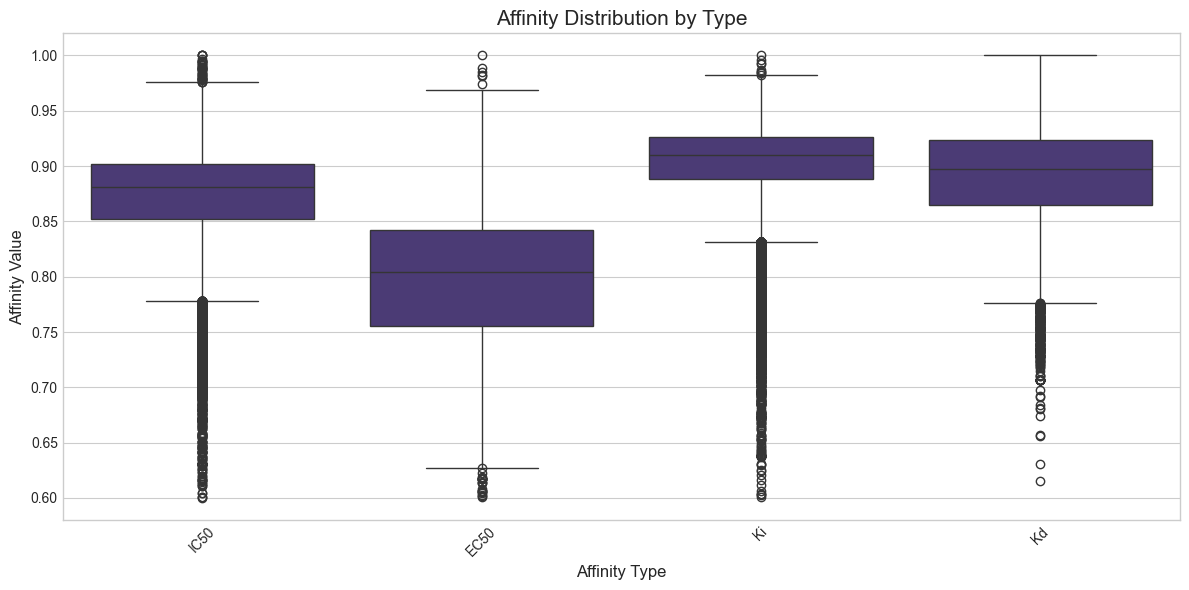


Affinity statistics by type:
                 count      mean       std       min       25%       50%  \
AffinityType                                                               
EC50           80724.0  0.796544  0.058853  0.600922  0.755866  0.804585   
IC50          624692.0  0.874566  0.035742  0.600017  0.852196  0.881351   
Kd             15603.0  0.889313  0.045688  0.615291  0.864736  0.897206   
Ki            194199.0  0.904322  0.031803  0.600490  0.888200  0.910199   

                   75%  max  
AffinityType                 
EC50          0.841772  1.0  
IC50          0.901683  1.0  
Kd            0.923915  1.0  
Ki            0.925844  1.0  

Processed dataframe saved to 'bindingdb_processed.csv'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, Lipinski
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Load the dataset
file_path = r"C:\Users\kani1\OneDrive\Desktop\gdg_hackathon_25\MolGenX-api\MolGenX-backend\data\cleaned_bindingDB.csv"  # Update with your file path
df = pd.read_csv(file_path)

print(f"Dataset loaded with {len(df)} compound-protein pairs")
print(f"Columns: {df.columns.tolist()}")

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)

# Check unique affinity types
if 'AffinityType' in df.columns:
    affinity_types = df['AffinityType'].value_counts()
    print("\nAffinity Types:")
    print(affinity_types)

# Filter out rows with missing essential data
df_filtered = df.dropna(subset=['smiles', 'target_seq', 'affinity']).copy()
print(f"\nFiltered dataset contains {len(df_filtered)} rows after removing missing values")

# Validate SMILES strings
valid_mols = []
valid_indices = []
invalid_smiles = []

for i, smiles in tqdm(enumerate(df_filtered['smiles']), total=len(df_filtered), desc="Validating SMILES"):
    if pd.isna(smiles):
        invalid_smiles.append(i)
        continue
        
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        valid_mols.append(mol)
        valid_indices.append(i)
    else:
        invalid_smiles.append(i)

# Create a new dataframe with only valid molecules
valid_df = df_filtered.iloc[valid_indices].copy().reset_index(drop=True)
print(f"\nValid SMILES: {len(valid_df)} out of {len(df_filtered)} ({len(valid_df)/len(df_filtered)*100:.2f}%)")

# Calculate molecular properties
print("Calculating molecular properties...")
valid_df['qed'] = [QED.qed(mol) for mol in tqdm(valid_mols, desc="Calculating QED")]
valid_df['logp'] = [Descriptors.MolLogP(mol) for mol in tqdm(valid_mols, desc="Calculating LogP")]
valid_df['molecular_weight'] = [Descriptors.MolWt(mol) for mol in tqdm(valid_mols, desc="Calculating MW")]
valid_df['h_donors'] = [Descriptors.NumHDonors(mol) for mol in valid_mols]
valid_df['h_acceptors'] = [Descriptors.NumHAcceptors(mol) for mol in valid_mols]
valid_df['rotatable_bonds'] = [Descriptors.NumRotatableBonds(mol) for mol in valid_mols]
valid_df['aromatic_rings'] = [len(mol.GetAromaticAtoms()) > 0 for mol in valid_mols]

# Summary statistics for molecular properties
print("\nMolecular Property Summary Statistics:")
summary = valid_df[['qed', 'logp', 'molecular_weight', 'affinity']].describe()
print(summary)

# Calculate and display averages
avg_qed = valid_df['qed'].mean()
avg_mw = valid_df['molecular_weight'].mean()
avg_logp = valid_df['logp'].mean()
avg_affinity = valid_df['affinity'].mean()

print(f"\nAverage QED score: {avg_qed:.4f}")
print(f"Average molecular weight: {avg_mw:.2f} g/mol")
print(f"Average LogP: {avg_logp:.2f}")
print(f"Average affinity value: {avg_affinity:.4f}")

# Protein sequence statistics
# Calculate sequence lengths
valid_df['protein_length'] = valid_df['target_seq'].str.len()

# Summary statistics for protein sequences
print("\nProtein Sequence Summary Statistics:")
protein_summary = valid_df['protein_length'].describe()
print(protein_summary)

# Count unique protein sequences
unique_proteins = valid_df['target_seq'].nunique()
print(f"Unique protein sequences: {unique_proteins}")

# Distribution of protein lengths
print(f"\nProtein length distribution:")
bins = [0, 100, 200, 300, 400, 500, 1000, 5000]
labels = ['<100', '100-200', '200-300', '300-400', '400-500', '500-1000', '>1000']
valid_df['length_category'] = pd.cut(valid_df['protein_length'], bins=bins, labels=labels)
length_counts = valid_df['length_category'].value_counts().sort_index()

for category, count in length_counts.items():
    print(f"{category}: {count} proteins ({count/len(valid_df)*100:.2f}%)")

# Molecular property distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution of Molecular Properties in BindingDB Dataset', fontsize=20)

# QED Distribution
sns.histplot(valid_df['qed'], kde=True, bins=30, ax=axes[0, 0])
axes[0, 0].set_title('QED Score Distribution', fontsize=15)
axes[0, 0].set_xlabel('QED Score', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].axvline(avg_qed, color='red', linestyle='--', label=f'Mean: {avg_qed:.2f}')
axes[0, 0].legend()

# LogP Distribution
sns.histplot(valid_df['logp'], kde=True, bins=30, ax=axes[0, 1])
axes[0, 1].set_title('LogP Distribution', fontsize=15)
axes[0, 1].set_xlabel('LogP', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].axvline(avg_logp, color='red', linestyle='--', label=f'Mean: {avg_logp:.2f}')
# Add Lipinski rule line at LogP = 5
axes[0, 1].axvline(5, color='green', linestyle='--', label='Lipinski cutoff')
axes[0, 1].legend()

# Molecular Weight Distribution
sns.histplot(valid_df['molecular_weight'], kde=True, bins=30, ax=axes[0, 2])
axes[0, 2].set_title('Molecular Weight Distribution', fontsize=15)
axes[0, 2].set_xlabel('Molecular Weight (g/mol)', fontsize=12)
axes[0, 2].set_ylabel('Count', fontsize=12)
axes[0, 2].axvline(avg_mw, color='red', linestyle='--', label=f'Mean: {avg_mw:.2f}')
# Add Lipinski rule line at MW = 500
axes[0, 2].axvline(500, color='green', linestyle='--', label='Lipinski cutoff')
axes[0, 2].legend()

# Affinity Distribution
sns.histplot(valid_df['affinity'], kde=True, bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Affinity Distribution', fontsize=15)
axes[1, 0].set_xlabel('Affinity Value', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].axvline(avg_affinity, color='red', linestyle='--', label=f'Mean: {avg_affinity:.2f}')
axes[1, 0].legend()

# Protein Length Distribution
sns.histplot(valid_df['protein_length'], kde=True, bins=30, ax=axes[1, 1])
axes[1, 1].set_title('Protein Sequence Length Distribution', fontsize=15)
axes[1, 1].set_xlabel('Sequence Length (amino acids)', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].axvline(valid_df['protein_length'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {valid_df["protein_length"].mean():.0f}')
axes[1, 1].legend()

# AffinityType Distribution if available
if 'AffinityType' in valid_df.columns:
    sns.countplot(x='AffinityType', data=valid_df, ax=axes[1, 2])
    axes[1, 2].set_title('Affinity Type Distribution', fontsize=15)
    axes[1, 2].set_xlabel('Affinity Type', fontsize=12)
    axes[1, 2].set_ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
else:
    fig.delaxes(axes[1, 2])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('bindingdb_properties_distribution.png', dpi=300)
plt.show()

# Create pairplot for key properties
print("Generating pairplot (this may take a while for large datasets)...")
plt.figure(figsize=(14, 10))
plot_df = valid_df[['qed', 'logp', 'molecular_weight', 'affinity']].sample(min(5000, len(valid_df)))
sns.pairplot(plot_df, diag_kind='kde')
plt.suptitle('Relationships Between Molecular Properties and Affinity', y=1.02, fontsize=18)
plt.savefig('bindingdb_properties_pairplot.png', dpi=300)
plt.show()

# Drug-likeness analysis (Lipinski's Rule of 5)
def lipinski_violations(mol):
    """Count Lipinski's Rule of 5 violations"""
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)
    
    violations = 0
    if mw > 500: violations += 1
    if logp > 5: violations += 1
    if h_donors > 5: violations += 1
    if h_acceptors > 10: violations += 1
    
    return violations

lipinski_counts = [lipinski_violations(mol) for mol in valid_mols]
valid_df['lipinski_violations'] = lipinski_counts

violation_counts = valid_df['lipinski_violations'].value_counts().sort_index()
print("\nLipinski's Rule of 5 Violations:")
for violations, count in violation_counts.items():
    print(f"{violations} violations: {count} compounds ({count/len(valid_df)*100:.2f}%)")

# Categorize QED scores
qed_ranges = [
    (0, 0.3, 'Very Low'),
    (0.3, 0.5, 'Low'),
    (0.5, 0.7, 'Medium'),
    (0.7, 1.0, 'High')
]

# Create QED category column
valid_df['qed_category'] = 'Unknown'
for low, high, label in qed_ranges:
    mask = (valid_df['qed'] >= low) & (valid_df['qed'] < high)
    valid_df.loc[mask, 'qed_category'] = label

qed_category_counts = valid_df['qed_category'].value_counts().sort_index()
print("\nQED Score Distribution:")
for category, count in qed_category_counts.items():
    print(f"{category}: {count} compounds ({count/len(valid_df)*100:.2f}%)")

# Analyze relationship between affinity and molecular properties
print("\nCorrelation between affinity and molecular properties:")
correlation = valid_df[['affinity', 'qed', 'logp', 'molecular_weight']].corr()
print(correlation['affinity'])

# Create bins for affinity values for better visualization
print("\nAnalyzing molecular properties by affinity range...")
affinity_quantiles = pd.qcut(valid_df['affinity'], q=4)
valid_df['affinity_range'] = affinity_quantiles

# Calculate mean properties by affinity range
affinity_analysis = valid_df.groupby('affinity_range')[['qed', 'logp', 'molecular_weight']].mean()
print("\nAverage properties by affinity range:")
print(affinity_analysis)

# Visualize relationship between affinity and properties
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Relationship Between Affinity and Molecular Properties', fontsize=20)

# Box plots for QED by affinity range
sns.boxplot(x='affinity_range', y='qed', data=valid_df, ax=axes[0])
axes[0].set_title('QED by Affinity Range', fontsize=15)
axes[0].set_xlabel('Affinity Range', fontsize=12)
axes[0].set_ylabel('QED Score', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Box plots for LogP by affinity range
sns.boxplot(x='affinity_range', y='logp', data=valid_df, ax=axes[1])
axes[1].set_title('LogP by Affinity Range', fontsize=15)
axes[1].set_xlabel('Affinity Range', fontsize=12)
axes[1].set_ylabel('LogP', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Box plots for MW by affinity range
sns.boxplot(x='affinity_range', y='molecular_weight', data=valid_df, ax=axes[2])
axes[2].set_title('Molecular Weight by Affinity Range', fontsize=15)
axes[2].set_xlabel('Affinity Range', fontsize=12)
axes[2].set_ylabel('Molecular Weight (g/mol)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('affinity_vs_properties.png', dpi=300)
plt.show()

# Analysis of protein targets and their ligands
ligands_per_target = valid_df.groupby('target_seq').size()

print("\nLigands per protein target:")
print(f"  Mean: {ligands_per_target.mean():.2f}")
print(f"  Median: {ligands_per_target.median():.0f}")
print(f"  Min: {ligands_per_target.min()}")
print(f"  Max: {ligands_per_target.max()}")
print(f"  Targets with only one ligand: {(ligands_per_target == 1).sum()} ({(ligands_per_target == 1).sum()/len(ligands_per_target)*100:.2f}%)")

# Create visualization of ligands per target distribution
plt.figure(figsize=(12, 6))
sns.histplot(ligands_per_target.values, bins=30, kde=True)
plt.title('Distribution of Ligands per Protein Target', fontsize=15)
plt.xlabel('Number of Ligands', fontsize=12)
plt.ylabel('Count of Proteins', fontsize=12)
plt.axvline(ligands_per_target.mean(), color='red', linestyle='--', label=f'Mean: {ligands_per_target.mean():.2f}')
plt.axvline(ligands_per_target.median(), color='green', linestyle='--', label=f'Median: {ligands_per_target.median():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('ligands_per_target_distribution.png', dpi=300)
plt.show()

# Analyze top protein targets by number of ligands
top_targets = ligands_per_target.sort_values(ascending=False).head(10)
top_target_details = []

for target_seq, count in top_targets.items():
    # Calculate average affinity for this target
    target_ligands = valid_df[valid_df['target_seq'] == target_seq]
    avg_target_affinity = target_ligands['affinity'].mean()
    
    top_target_details.append({
        'sequence_length': len(target_seq),
        'ligand_count': count,
        'avg_affinity': avg_target_affinity,
        'sequence_prefix': target_seq[:50] + '...'  # Show first 50 chars
    })

top_targets_df = pd.DataFrame(top_target_details)
print("\nTop 10 protein targets by number of ligands:")
print(top_targets_df)

# Analyze affinity distribution by AffinityType if available
if 'AffinityType' in valid_df.columns and valid_df['AffinityType'].nunique() > 1:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='AffinityType', y='affinity', data=valid_df)
    plt.title('Affinity Distribution by Type', fontsize=15)
    plt.xlabel('Affinity Type', fontsize=12)
    plt.ylabel('Affinity Value', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('affinity_by_type.png', dpi=300)
    plt.show()
    
    # Summarize affinity by type
    affinity_by_type = valid_df.groupby('AffinityType')['affinity'].describe()
    print("\nAffinity statistics by type:")
    print(affinity_by_type)

# Save the processed dataframe with all computed properties
valid_df.to_csv('bindingdb_processed.csv', index=False)
print("\nProcessed dataframe saved to 'bindingdb_processed.csv'")

CHEMBL

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, Lipinski
from rdkit.Chem import MolSurf
import os
import warnings
warnings.filterwarnings('ignore')
import concurrent.futures
import time
from tqdm.auto import tqdm
import cupy as cp  # GPU-accelerated array library
from pandarallel import pandarallel  # Parallel pandas operations

# Initialize pandarallel for multi-core processing
pandarallel.initialize(progress_bar=True, nb_workers=8)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

def load_smiles_from_smi(file_path):
    """Load SMILES from a .smi file"""
    smiles_list = []
    
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:  # Make sure line isn't empty
                smiles_list.append(parts[0])  # First part is always SMILES
                
    print(f"Loaded {len(smiles_list)} SMILES strings")
    return smiles_list

def calculate_properties_batch(smiles_batch):
    """Calculate properties for a batch of SMILES strings in parallel"""
    results = []
    valid_mols = []
    valid_smiles = []
    
    for smiles in smiles_batch:
        if pd.isna(smiles):
            continue
            
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            valid_mols.append(mol)
            valid_smiles.append(smiles)
    
    for mol, smiles in zip(valid_mols, valid_smiles):
        props = {
            'smiles': smiles,
            'qed': QED.qed(mol),
            'logp': Descriptors.MolLogP(mol),
            'molecular_weight': Descriptors.MolWt(mol),
            'h_donors': Descriptors.NumHDonors(mol),
            'h_acceptors': Descriptors.NumHAcceptors(mol),
            'rotatable_bonds': Descriptors.NumRotatableBonds(mol),
            'aromatic_rings': len(Chem.GetSSSR(mol)),
            'tpsa': MolSurf.TPSA(mol),
            'hac': mol.GetNumHeavyAtoms(),
            'fsp3': Descriptors.FractionCSP3(mol),
            'lipinski_violations': lipinski_violations(mol),
            'veber_violations': veber_violations(mol),
            'ghose_violations': ghose_violations(mol)
        }
        results.append(props)
    
    return results

# Drug-likeness rule functions
def lipinski_violations(mol):
    """Count Lipinski's Rule of 5 violations"""
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)
    
    violations = 0
    if mw > 500: violations += 1
    if logp > 5: violations += 1
    if h_donors > 5: violations += 1
    if h_acceptors > 10: violations += 1
    
    return violations

def veber_violations(mol):
    """Count Veber rule violations (≤10 rotatable bonds and TPSA ≤140)"""
    rotatable_bonds = Descriptors.NumRotatableBonds(mol)
    tpsa = MolSurf.TPSA(mol)
    
    violations = 0
    if rotatable_bonds > 10: violations += 1
    if tpsa > 140: violations += 1
    
    return violations

def ghose_violations(mol):
    """Count Ghose filter violations"""
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    atom_count = mol.GetNumHeavyAtoms()
    molar_refractivity = Descriptors.MolMR(mol)
    
    violations = 0
    if mw < 160 or mw > 480: violations += 1
    if logp < -0.4 or logp > 5.6: violations += 1
    if atom_count < 20 or atom_count > 70: violations += 1
    if molar_refractivity < 40 or molar_refractivity > 130: violations += 1
    
    return violations

# Function to process a file in parallel using NVIDIA L4
def process_smiles_file_parallel(file_path):
    start_time = time.time()
    print(f"Starting processing of {file_path}...")
    
    # Load SMILES
    smiles_list = load_smiles_from_smi(file_path)
    
    # Create initial dataframe
    df = pd.DataFrame({'smiles': smiles_list})
    
    # Determine optimal batch size for the GPU
    # L4 has good memory, we can process large batches
    batch_size = 10000
    num_batches = (len(df) + batch_size - 1) // batch_size  # Ceiling division
    
    all_results = []
    total_processed = 0
    
    print(f"\nProcessing SMILES in {num_batches} batches using NVIDIA L4 GPU...")
    
    # Create batches for parallel processing
    with concurrent.futures.ProcessPoolExecutor(max_workers=8) as executor:
        # Submit all batches as separate tasks
        futures = []
        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, len(df))
            batch = df.iloc[start_idx:end_idx]['smiles'].tolist()
            futures.append(executor.submit(calculate_properties_batch, batch))
        
        # Process results as they complete
        for i, future in enumerate(tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc="Processing batches")):
            batch_results = future.result()
            all_results.extend(batch_results)
            total_processed += len(batch_results)
    
    # Convert results to DataFrame
    valid_df = pd.DataFrame(all_results)
    
    end_time = time.time()
    processing_time = end_time - start_time
    
    print(f"\nProcessed {total_processed} valid SMILES out of {len(df)} ({total_processed/len(df)*100:.2f}%)")
    print(f"Total processing time: {processing_time:.2f} seconds")
    print(f"Processing speed: {len(df)/processing_time:.2f} molecules/second")
    
    # Categorize QED scores
    qed_ranges = [
        (0, 0.3, 'Very Low'),
        (0.3, 0.5, 'Low'),
        (0.5, 0.7, 'Medium'),
        (0.7, 1.0, 'High')
    ]

    # Create QED category column
    valid_df['qed_category'] = 'Unknown'
    for low, high, label in qed_ranges:
        mask = (valid_df['qed'] >= low) & (valid_df['qed'] < high)
        valid_df.loc[mask, 'qed_category'] = label
    
    return valid_df

# Run the analysis on a SMILES file
def analyze_smiles_file(file_path):
    # Process the file with GPU acceleration
    valid_df = process_smiles_file_parallel(file_path)
    
    # Use GPU for numerical calculations where possible
    try:
        summary_stats = valid_df.describe()
        
        # Calculate and display averages
        avg_qed = valid_df['qed'].mean()
        avg_mw = valid_df['molecular_weight'].mean()
        avg_logp = valid_df['logp'].mean()

        print("\nMolecular Property Summary Statistics:")
        properties_cols = ['qed', 'logp', 'molecular_weight', 'h_donors', 'h_acceptors', 
                          'rotatable_bonds', 'aromatic_rings', 'tpsa', 'hac', 'fsp3']
        summary = valid_df[properties_cols].describe()
        print(summary)

        print(f"\nAverage QED score: {avg_qed:.4f}")
        print(f"Average molecular weight: {avg_mw:.2f} g/mol")
        print(f"Average LogP: {avg_logp:.2f}")

        # Display rule violations statistics
        print("\nLipinski's Rule of 5 Violations:")
        lipinski_counts = valid_df['lipinski_violations'].value_counts().sort_index()
        for violations, count in lipinski_counts.items():
            print(f"{violations} violations: {count} compounds ({count/len(valid_df)*100:.2f}%)")

        print("\nVeber Rule Violations:")
        veber_counts = valid_df['veber_violations'].value_counts().sort_index()
        for violations, count in veber_counts.items():
            print(f"{violations} violations: {count} compounds ({count/len(valid_df)*100:.2f}%)")

        print("\nGhose Filter Violations:")
        ghose_counts = valid_df['ghose_violations'].value_counts().sort_index()
        for violations, count in ghose_counts.items():
            print(f"{violations} violations: {count} compounds ({count/len(valid_df)*100:.2f}%)")

        # QED Score Distribution
        print("\nQED Score Distribution:")
        qed_category_counts = valid_df['qed_category'].value_counts().sort_index()
        for category, count in qed_category_counts.items():
            print(f"{category}: {count} compounds ({count/len(valid_df)*100:.2f}%)")
    
        # Generate visualizations (this happens on CPU since matplotlib doesn't use GPU)
        print("\nGenerating visualizations...")
        
        # Visualization of property distributions
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Distribution of Molecular Properties', fontsize=20)

        # QED Distribution
        sns.histplot(valid_df['qed'], kde=True, bins=30, ax=axes[0, 0])
        axes[0, 0].set_title('QED Score Distribution', fontsize=15)
        axes[0, 0].set_xlabel('QED Score', fontsize=12)
        axes[0, 0].set_ylabel('Count', fontsize=12)
        axes[0, 0].axvline(avg_qed, color='red', linestyle='--', label=f'Mean: {avg_qed:.2f}')
        axes[0, 0].legend()

        # LogP Distribution
        sns.histplot(valid_df['logp'], kde=True, bins=30, ax=axes[0, 1])
        axes[0, 1].set_title('LogP Distribution', fontsize=15)
        axes[0, 1].set_xlabel('LogP', fontsize=12)
        axes[0, 1].set_ylabel('Count', fontsize=12)
        axes[0, 1].axvline(avg_logp, color='red', linestyle='--', label=f'Mean: {avg_logp:.2f}')
        axes[0, 1].axvline(5, color='green', linestyle='--', label='Lipinski cutoff')
        axes[0, 1].legend()

        # Molecular Weight Distribution
        sns.histplot(valid_df['molecular_weight'], kde=True, bins=30, ax=axes[0, 2])
        axes[0, 2].set_title('Molecular Weight Distribution', fontsize=15)
        axes[0, 2].set_xlabel('Molecular Weight (g/mol)', fontsize=12)
        axes[0, 2].set_ylabel('Count', fontsize=12)
        axes[0, 2].axvline(avg_mw, color='red', linestyle='--', label=f'Mean: {avg_mw:.2f}')
        axes[0, 2].axvline(500, color='green', linestyle='--', label='Lipinski cutoff')
        axes[0, 2].legend()

        # TPSA Distribution
        sns.histplot(valid_df['tpsa'], kde=True, bins=30, ax=axes[1, 0])
        axes[1, 0].set_title('Total Polar Surface Area Distribution', fontsize=15)
        axes[1, 0].set_xlabel('TPSA (Å²)', fontsize=12)
        axes[1, 0].set_ylabel('Count', fontsize=12)
        axes[1, 0].axvline(valid_df['tpsa'].mean(), color='red', linestyle='--', 
                           label=f'Mean: {valid_df["tpsa"].mean():.2f}')
        axes[1, 0].axvline(140, color='green', linestyle='--', label='Veber cutoff')
        axes[1, 0].legend()

        # Rotatable Bonds Distribution
        sns.histplot(valid_df['rotatable_bonds'], kde=True, bins=30, ax=axes[1, 1])
        axes[1, 1].set_title('Rotatable Bonds Distribution', fontsize=15)
        axes[1, 1].set_xlabel('Number of Rotatable Bonds', fontsize=12)
        axes[1, 1].set_ylabel('Count', fontsize=12)
        axes[1, 1].axvline(valid_df['rotatable_bonds'].mean(), color='red', linestyle='--', 
                           label=f'Mean: {valid_df["rotatable_bonds"].mean():.2f}')
        axes[1, 1].axvline(10, color='green', linestyle='--', label='Veber cutoff')
        axes[1, 1].legend()

        # Fraction sp3 Distribution
        sns.histplot(valid_df['fsp3'], kde=True, bins=30, ax=axes[1, 2])
        axes[1, 2].set_title('Fraction of sp³ Carbons Distribution', fontsize=15)
        axes[1, 2].set_xlabel('Fraction sp³', fontsize=12)
        axes[1, 2].set_ylabel('Count', fontsize=12)
        axes[1, 2].axvline(valid_df['fsp3'].mean(), color='red', linestyle='--', 
                           label=f'Mean: {valid_df["fsp3"].mean():.2f}')
        axes[1, 2].legend()

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.savefig('molecular_properties_distribution.png', dpi=300)
        
        # Create pairplot for key properties using a sample to speed up visualization
        print("Generating pairplot (using a sample of the data)...")
        plt.figure(figsize=(14, 10))
        sample_size = min(5000, len(valid_df))
        plot_df = valid_df[['qed', 'logp', 'molecular_weight', 'tpsa', 'rotatable_bonds']].sample(sample_size)
        sns.pairplot(plot_df, diag_kind='kde')
        plt.suptitle('Relationships Between Molecular Properties', y=1.02, fontsize=18)
        plt.savefig('molecular_properties_pairplot.png', dpi=300)

        # Rule violations count visualization
        rule_violations = pd.melt(valid_df[['lipinski_violations', 'veber_violations', 'ghose_violations']], 
                                   var_name='Rule Type', value_name='Violations')

        plt.figure(figsize=(12, 6))
        sns.countplot(data=rule_violations, x='Violations', hue='Rule Type')
        plt.title('Drug-likeness Rule Violations', fontsize=15)
        plt.xlabel('Number of Violations', fontsize=12)
        plt.ylabel('Count of Molecules', fontsize=12)
        plt.legend(title='Rule Set')
        plt.savefig('rule_violations.png', dpi=300)
        
    except Exception as e:
        print(f"Error in analysis: {e}")
    
    # Save the processed dataframe with all computed properties
    output_name = os.path.splitext(os.path.basename(file_path))[0] + "_processed.csv"
    valid_df.to_csv(output_name, index=False)
    print(f"\nProcessed dataframe saved to '{output_name}'")
    
    return valid_df

# Main execution
if __name__ == "__main__":
    file_path = "your_smiles_file.smi"  # Update with your file path
    processed_data = analyze_smiles_file(file_path)

Loaded 888651 SMILES strings


Validating SMILES: 100%|██████████| 888651/888651 [04:14<00:00, 3494.44it/s]



Valid SMILES: 888651 out of 888651 (100.00%)

Calculating molecular properties...


Calculating properties: 100%|██████████| 888651/888651 [37:15<00:00, 397.45it/s]  


KeyboardInterrupt: 

DrugBank

Reading SMILES from C:\Users\kani1\OneDrive\Desktop\gdg_hackathon_25\MolGenX-api\MolGenX-backend\data\drugbank_smiles.txt...
Processing 10597 SMILES strings...


Validating SMILES: 100%|██████████| 10597/10597 [00:01<00:00, 7325.61it/s]


Valid SMILES: 10597 out of 10597 (100.00%)


Calculating properties: 100%|██████████| 10597/10597 [00:16<00:00, 660.55it/s]


Saved processed data to C:\Users\kani1\OneDrive\Desktop\gdg_hackathon_25\MolGenX-api\MolGenX-backend\data\drugbank_smiles_processed.csv

Summary Statistics:
                qed  molecular_weight          logP
count  10597.000000      10597.000000  10597.000000
mean       0.505285        379.420811      1.973923
std        0.223449        310.497772      3.045126
min        0.003201          3.016029    -83.666800
25%        0.349979        244.297000      0.369000
50%        0.514063        340.114000      2.287520
75%        0.686117        439.313000      3.789600
max        0.944151       8272.344000     24.570500
Saved distributions plot to C:\Users\kani1\OneDrive\Desktop\gdg_hackathon_25\MolGenX-api\MolGenX-backend\data\drugbank_smiles_distributions.png
Saved pairplot to C:\Users\kani1\OneDrive\Desktop\gdg_hackathon_25\MolGenX-api\MolGenX-backend\data\drugbank_smiles_pairplot.png

Lipinski's Rule of 5 Violations:
0 violations: 7968 compounds (75.19%)
1 violations: 1331 compounds (

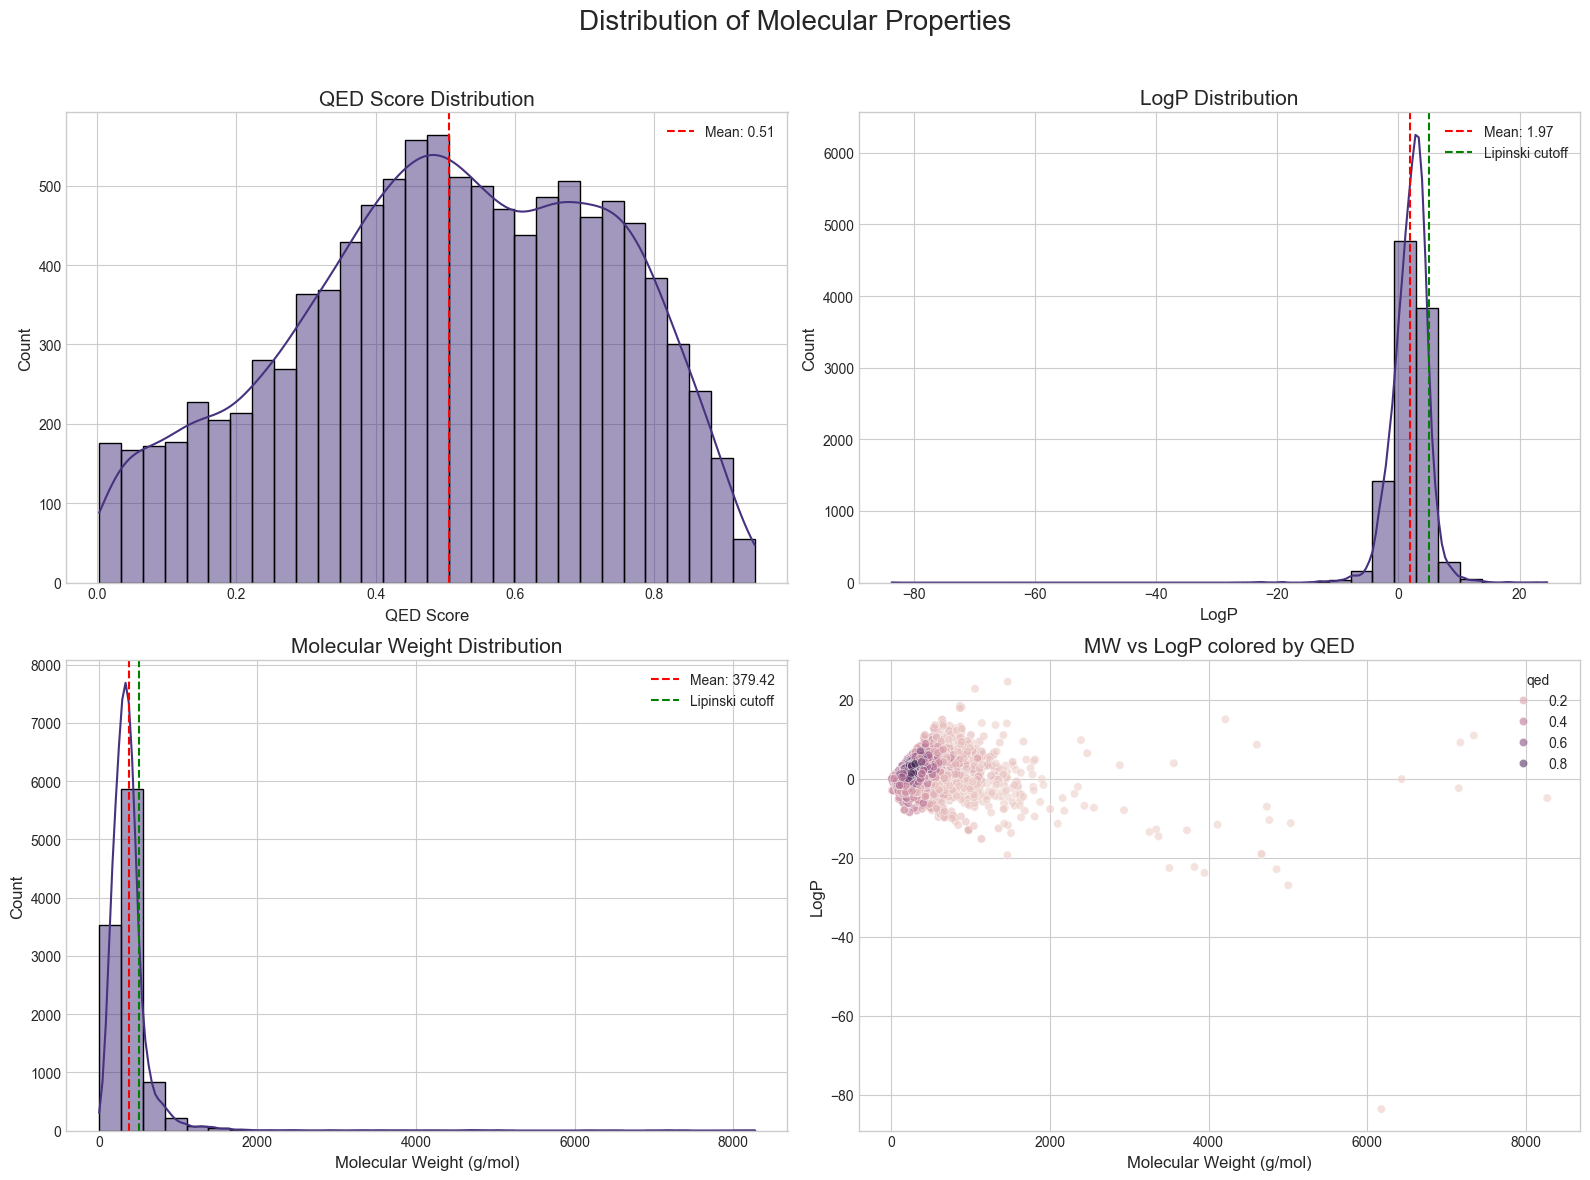

<Figure size 1400x1000 with 0 Axes>

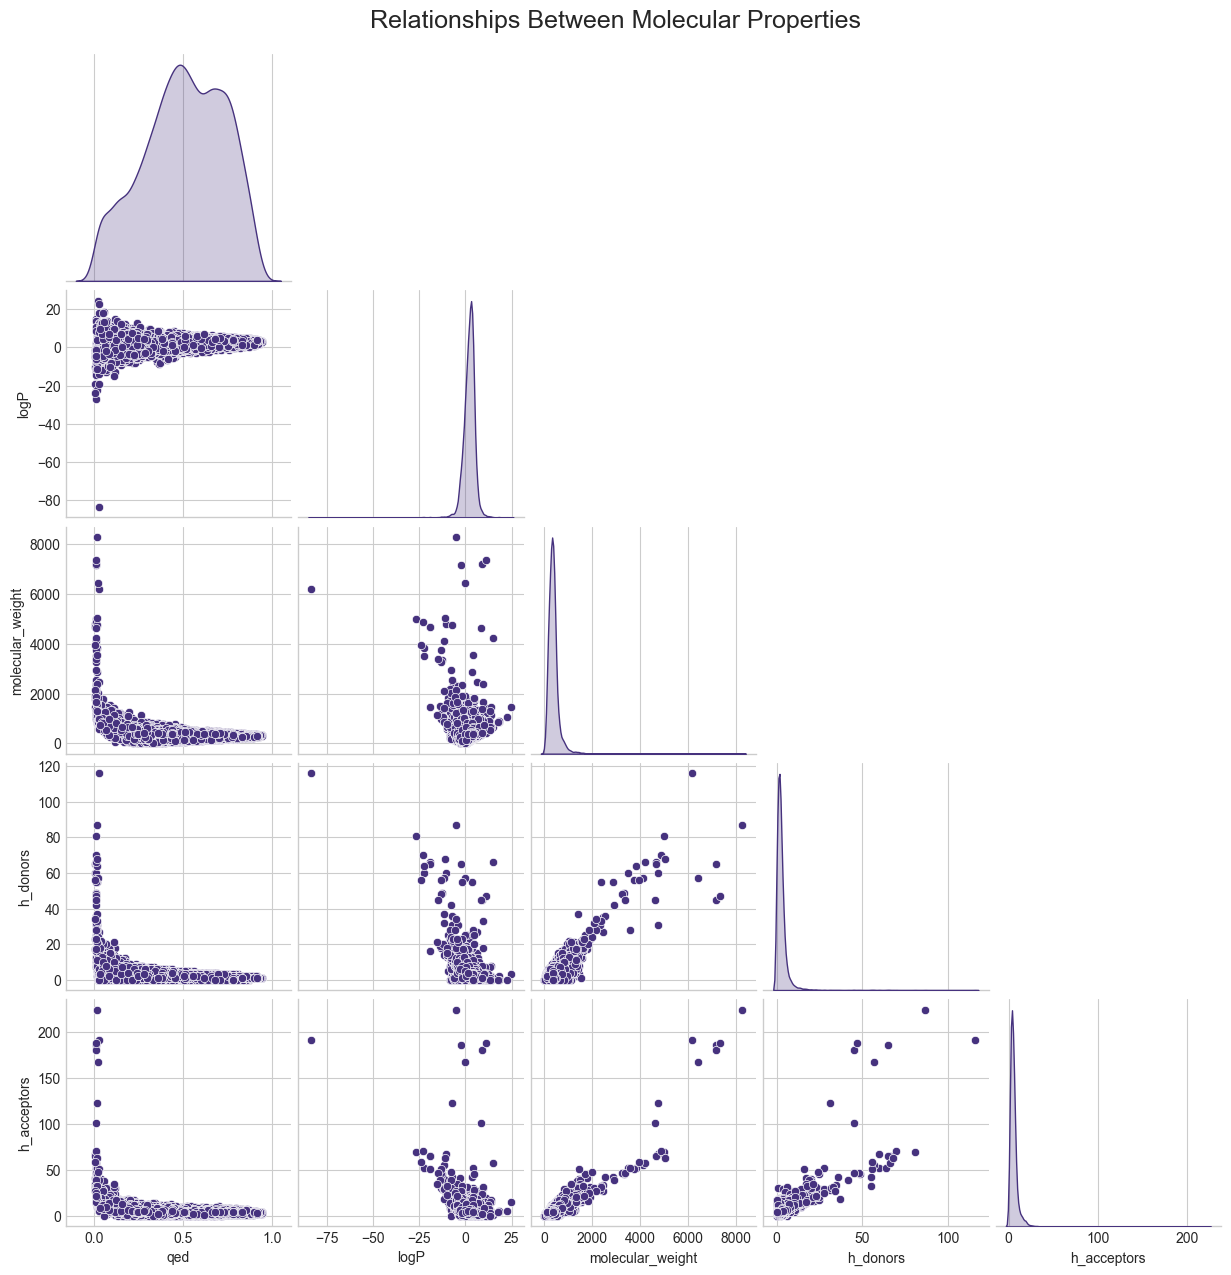

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, QED
from tqdm import tqdm
import os

def process_smiles_file(file_path):
    """Process a text file containing SMILES strings"""
    # Set plotting style
    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_palette("viridis")
    
    print(f"Reading SMILES from {file_path}...")
    # Read the text file line by line
    with open(file_path, 'r') as f:
        smiles_list = [line.strip() for line in f if line.strip()]
    
    print(f"Processing {len(smiles_list)} SMILES strings...")
    
    # Initialize lists to store data
    valid_smiles = []
    valid_mols = []
    invalid_smiles = []
    
    # Validate SMILES strings
    for i, smiles in enumerate(tqdm(smiles_list, desc="Validating SMILES")):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            valid_smiles.append(smiles)
            valid_mols.append(mol)
        else:
            invalid_smiles.append(smiles)
    
    print(f"Valid SMILES: {len(valid_smiles)} out of {len(smiles_list)} ({len(valid_smiles)/len(smiles_list)*100:.2f}%)")
    
    # Calculate molecular properties
    data = []
    for i, (smiles, mol) in enumerate(tqdm(zip(valid_smiles, valid_mols), 
                                          total=len(valid_smiles), 
                                          desc="Calculating properties")):
        props = {
            'smiles': smiles,
            'qed': QED.qed(mol),
            'molecular_weight': Descriptors.MolWt(mol),
            'logP': Descriptors.MolLogP(mol),
            'h_donors': Descriptors.NumHDonors(mol),
            'h_acceptors': Descriptors.NumHAcceptors(mol),
            'rotatable_bonds': Descriptors.NumRotatableBonds(mol),
            'aromatic_rings': len(Chem.GetSSSR(mol)),
            'heavy_atom_count': mol.GetNumHeavyAtoms()
        }
        data.append(props)
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Save to CSV
    output_csv = os.path.splitext(file_path)[0] + "_processed.csv"
    df.to_csv(output_csv, index=False)
    print(f"Saved processed data to {output_csv}")
    
    # Calculate summary statistics
    summary = df[['qed', 'molecular_weight', 'logP']].describe()
    print("\nSummary Statistics:")
    print(summary)
    
    # Visualize distributions
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Distribution of Molecular Properties', fontsize=20)
    
    # QED Distribution
    avg_qed = df['qed'].mean()
    sns.histplot(df['qed'], kde=True, bins=30, ax=axes[0, 0])
    axes[0, 0].set_title('QED Score Distribution', fontsize=15)
    axes[0, 0].set_xlabel('QED Score', fontsize=12)
    axes[0, 0].set_ylabel('Count', fontsize=12)
    axes[0, 0].axvline(avg_qed, color='red', linestyle='--', label=f'Mean: {avg_qed:.2f}')
    axes[0, 0].legend()
    
    # LogP Distribution
    avg_logp = df['logP'].mean()
    sns.histplot(df['logP'], kde=True, bins=30, ax=axes[0, 1])
    axes[0, 1].set_title('LogP Distribution', fontsize=15)
    axes[0, 1].set_xlabel('LogP', fontsize=12)
    axes[0, 1].set_ylabel('Count', fontsize=12)
    axes[0, 1].axvline(avg_logp, color='red', linestyle='--', label=f'Mean: {avg_logp:.2f}')
    axes[0, 1].axvline(5, color='green', linestyle='--', label='Lipinski cutoff')
    axes[0, 1].legend()
    
    # Molecular Weight Distribution
    avg_mw = df['molecular_weight'].mean()
    sns.histplot(df['molecular_weight'], kde=True, bins=30, ax=axes[1, 0])
    axes[1, 0].set_title('Molecular Weight Distribution', fontsize=15)
    axes[1, 0].set_xlabel('Molecular Weight (g/mol)', fontsize=12)
    axes[1, 0].set_ylabel('Count', fontsize=12)
    axes[1, 0].axvline(avg_mw, color='red', linestyle='--', label=f'Mean: {avg_mw:.2f}')
    axes[1, 0].axvline(500, color='green', linestyle='--', label='Lipinski cutoff')
    axes[1, 0].legend()
    
    # Property relationships
    sns.scatterplot(x='molecular_weight', y='logP', hue='qed', data=df, ax=axes[1, 1], alpha=0.6)
    axes[1, 1].set_title('MW vs LogP colored by QED', fontsize=15)
    axes[1, 1].set_xlabel('Molecular Weight (g/mol)', fontsize=12)
    axes[1, 1].set_ylabel('LogP', fontsize=12)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save the figure
    plt_output = os.path.splitext(file_path)[0] + "_distributions.png"
    plt.savefig(plt_output, dpi=300)
    print(f"Saved distributions plot to {plt_output}")
    
    # Create pairplot for a more comprehensive view
    plt.figure(figsize=(14, 10))
    sns.pairplot(df[['qed', 'logP', 'molecular_weight', 'h_donors', 'h_acceptors']], 
                 diag_kind='kde', corner=True)
    plt.suptitle('Relationships Between Molecular Properties', y=1.02, fontsize=18)
    
    # Save the pairplot
    pair_output = os.path.splitext(file_path)[0] + "_pairplot.png"
    plt.savefig(pair_output, dpi=300)
    print(f"Saved pairplot to {pair_output}")
    
    # Lipinski's Rule of 5 analysis
    df['lipinski_violations'] = df.apply(lambda x: 
        (x['molecular_weight'] > 500) + 
        (x['logP'] > 5) + 
        (x['h_donors'] > 5) + 
        (x['h_acceptors'] > 10), axis=1)
    
    violation_counts = df['lipinski_violations'].value_counts().sort_index()
    print("\nLipinski's Rule of 5 Violations:")
    for violations, count in violation_counts.items():
        print(f"{violations} violations: {count} compounds ({count/len(df)*100:.2f}%)")
    
    return df

if __name__ == "__main__":
    # Update this path to your SMILES text file
    file_path = r"C:\Users\kani1\OneDrive\Desktop\gdg_hackathon_25\MolGenX-api\MolGenX-backend\data\drugbank_smiles.txt"
    processed_data = process_smiles_file(file_path)